# Telco Customer Churn Sınıflandırma Projesi - Kapsamlı Veri Madenciliği

Bu proje, Telco müşteri churn veri seti kullanarak kapsamlı veri madenciliği sınıflandırma işlemlerini içerir. Hedef, müşterilerin churn (ayrılma) olasılığını tahmin etmektir.

## Adımlar:
1. **Veri Temizleme ve Ön İşleme**
2. **Keşifçi Veri Analizi (EDA)**
3. **Özellik Mühendisliği**
4. **Veri Hazırlığı ve Ayrı Ayrı Normalizasyon**
5. **PCA ile Özellik Çıkarımı**
6. **Modelleme ve Sınıflandırma Algoritmaları**

In [2]:
# Gerekli kütüphaneleri import edelim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Diğer
import warnings
warnings.filterwarnings('ignore')

print("Kütüphaneler başarıyla yüklendi!")

Kütüphaneler başarıyla yüklendi!


In [3]:
# Veri setini yükleyelim
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Veri seti başarıyla yüklendi!")
print(f"Veri seti boyutu: {df.shape}")
print("\nİlk 5 satır:")
df.head()

Veri seti başarıyla yüklendi!
Veri seti boyutu: (7043, 21)

İlk 5 satır:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Veri Temizleme ve Ön İşleme

In [4]:
# Veri ön işleme 
print("=== VERİ TEMİZLEME VE ÖN İŞLEME ===")

# Orijinal veriyi tekrar yükleyelim 
df_original = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_clean = df_original.copy()

# 1. Gereksiz sütunu kaldıralım
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop('customerID', axis=1)
    print("✓ customerID sütunu kaldırıldı")

# 2. Veri tiplerini kontrol edelim
print("\nVeri tipleri:")
print(df_clean.dtypes)

# 3. TotalCharges'ı sayısala çevirelim 
print(f"\nTotalCharges'da boş değer sayısı: {df_clean['TotalCharges'].isnull().sum()}")
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

=== VERİ TEMİZLEME VE ÖN İŞLEME ===
✓ customerID sütunu kaldırıldı

Veri tipleri:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

TotalCharges'da boş değer sayısı: 0


In [5]:
# Eksik ve duplike değer kontrolü
missing_values = df_clean.isnull().sum()
print(f"\nEksik değerler:\n{missing_values[missing_values > 0]}")

median_total_charges = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_total_charges)
print(f"✓ TotalCharges eksik değerleri medyan ({median_total_charges:.2f}) ile dolduruldu")

duplicates = df_clean.duplicated().sum()
print(f"\nDuplike satır sayısı: {duplicates}")
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("✓ Duplike satırlar kaldırıldı")


Eksik değerler:
TotalCharges    11
dtype: int64
✓ TotalCharges eksik değerleri medyan (1397.47) ile dolduruldu

Duplike satır sayısı: 22
✓ Duplike satırlar kaldırıldı


In [6]:
# Aykırı değer analizi (IQR yöntemi)
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print("\nAykırı değer analizi:")
for col in numeric_cols:
    outlier_count, lower, upper = detect_outliers_iqr(df_clean, col)
    print(f"{col}: {outlier_count} aykırı değer (Alt: {lower:.2f}, Üst: {upper:.2f})")


Aykırı değer analizi:
tenure: 0 aykırı değer (Alt: -60.00, Üst: 124.00)
MonthlyCharges: 0 aykırı değer (Alt: -45.48, Üst: 171.12)
TotalCharges: 0 aykırı değer (Alt: -4674.68, Üst: 8887.52)


In [7]:
# Kategorik değişkenleri encode edelim
categorical_cols = df_clean.select_dtypes(include=['object']).columns
print(f"\nKategorik değişkenler: {list(categorical_cols)}")

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col])
        print(f"✓ {col} label encoded")

multi_class_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=multi_class_cols, drop_first=True)
print("✓ Çok sınıflı kategorik değişkenler one-hot encoded")

print(f"\nTemizlenmiş veri seti boyutu: {df_clean.shape}")
print("\nÖn işlenmiş veri (ilk 5 satır):")
df_clean.head()


Kategorik değişkenler: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
✓ gender label encoded
✓ Partner label encoded
✓ Dependents label encoded
✓ PhoneService label encoded
✓ PaperlessBilling label encoded
✓ Churn label encoded
✓ Çok sınıflı kategorik değişkenler one-hot encoded

Temizlenmiş veri seti boyutu: (7021, 31)

Ön işlenmiş veri (ilk 5 satır):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 2. Keşifçi Veri Analizi (EDA)

In [8]:
# EDA - 1. Churn Dağılımı ve Temel İstatistikler
print("=== EDA 1: CHURN DAĞILIMI VE TEMEL İSTATİSTİKLER ===")

# Orijinal veriyi tekrar yükleyelim EDA için
df_eda = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'] = df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median())

# Temel istatistikler
print("Veri seti temel istatistikleri:")
print(df_eda.describe())

print(f"\nChurn dağılımı: {df_eda['Churn'].value_counts()}")
print(f"Churn oranı: {df_eda['Churn'].value_counts(normalize=True)['Yes']:.3f}")

=== EDA 1: CHURN DAĞILIMI VE TEMEL İSTATİSTİKLER ===
Veri seti temel istatistikleri:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2281.916928
std         0.368612    24.559481       30.090047   2265.270398
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    402.225000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000

Churn dağılımı: Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn oranı: 0.265


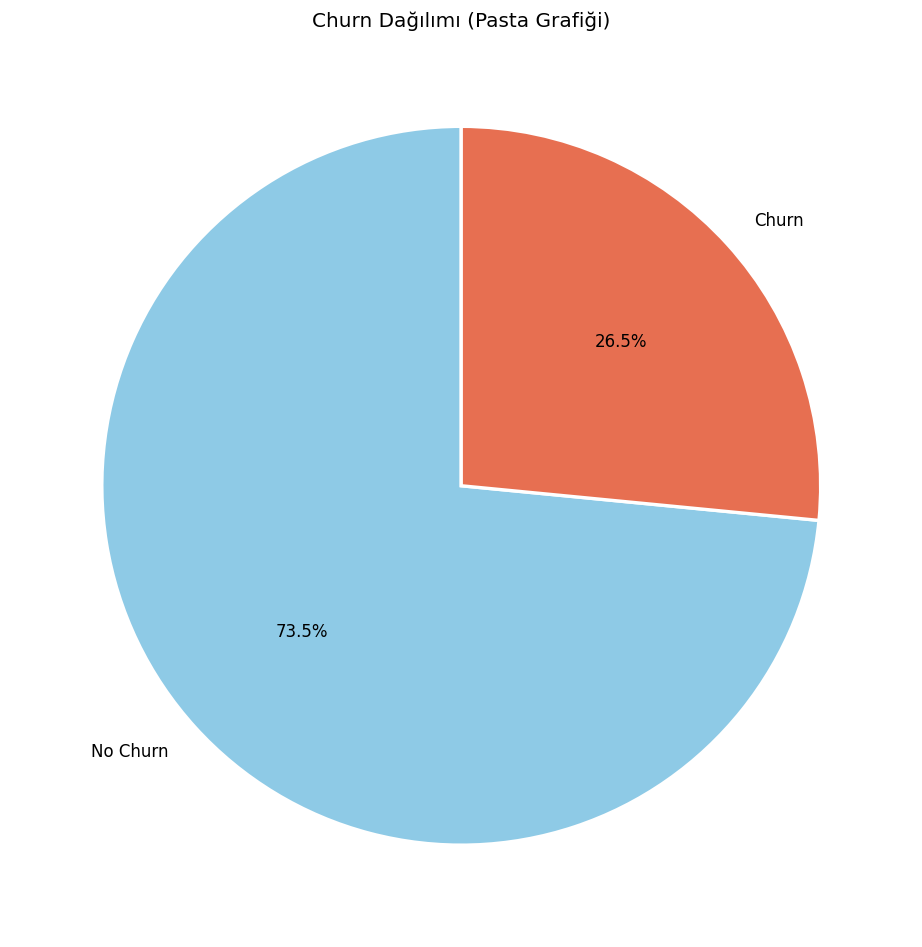

In [9]:
# EDA -  Churn dağılımı pasta grafiği
churn_counts = df_eda['Churn'].value_counts()

plt.figure(figsize=(8, 8), dpi=120)
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#8ecae6', '#e76f51'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Churn Dağılımı (Pasta Grafiği)')
plt.tight_layout()
plt.show()

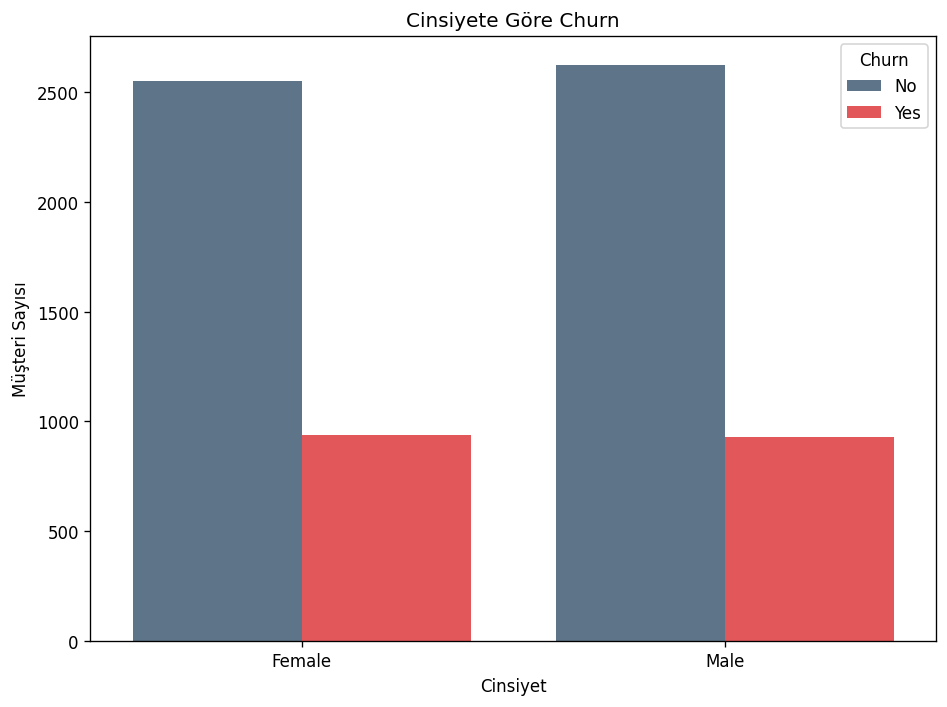

In [10]:
# EDA -  Cinsiyete göre churn
plt.figure(figsize=(8, 6), dpi=120)
sns.countplot(data=df_eda, x='gender', hue='Churn', palette={'No': '#577590', 'Yes': '#f94144'})
plt.title('Cinsiyete Göre Churn')
plt.xlabel('Cinsiyet')
plt.ylabel('Müşteri Sayısı')
plt.tight_layout()
plt.show()

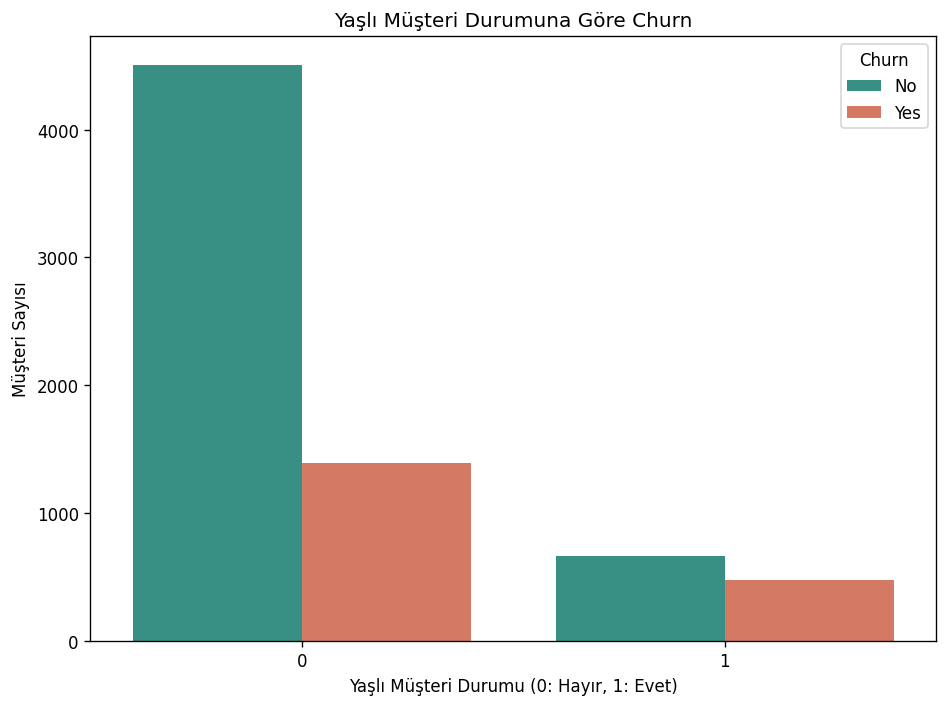

In [11]:
# EDA -  Yaşlı müşterilere göre churn
plt.figure(figsize=(8, 6), dpi=120)
sns.countplot(data=df_eda, x='SeniorCitizen', hue='Churn', palette={'No': '#2a9d8f', 'Yes': '#e76f51'})
plt.title('Yaşlı Müşteri Durumuna Göre Churn')
plt.xlabel('Yaşlı Müşteri Durumu (0: Hayır, 1: Evet)')
plt.ylabel('Müşteri Sayısı')
plt.tight_layout()
plt.show()

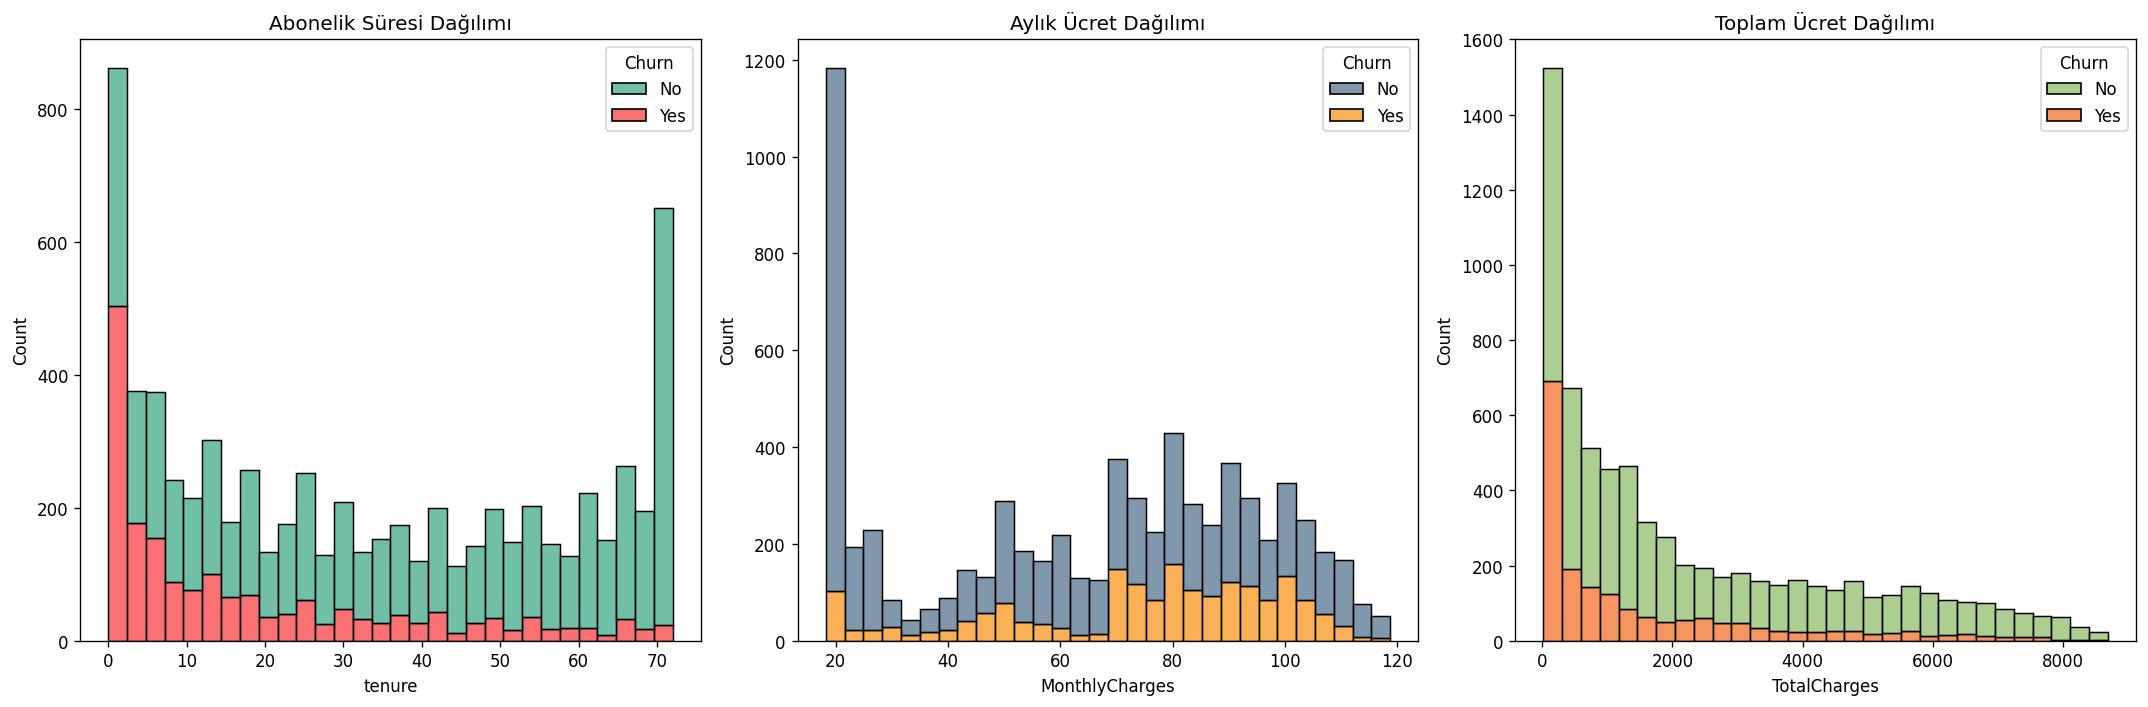

In [12]:
# EDA -  Sayısal değişken histogramları
plt.figure(figsize=(18, 6), dpi=120)

plt.subplot(1, 3, 1)
sns.histplot(data=df_eda, x='tenure', hue='Churn', multiple='stack', palette=['#43aa8b', '#f94144'], bins=30)
plt.title('Abonelik Süresi Dağılımı')

plt.subplot(1, 3, 2)
sns.histplot(data=df_eda, x='MonthlyCharges', hue='Churn', multiple='stack', palette=['#577590', '#f8961e'], bins=30)
plt.title('Aylık Ücret Dağılımı')

plt.subplot(1, 3, 3)
sns.histplot(data=df_eda, x='TotalCharges', hue='Churn', multiple='stack', palette=['#90be6d', '#f3722c'], bins=30)
plt.title('Toplam Ücret Dağılımı')

plt.tight_layout()
plt.show()

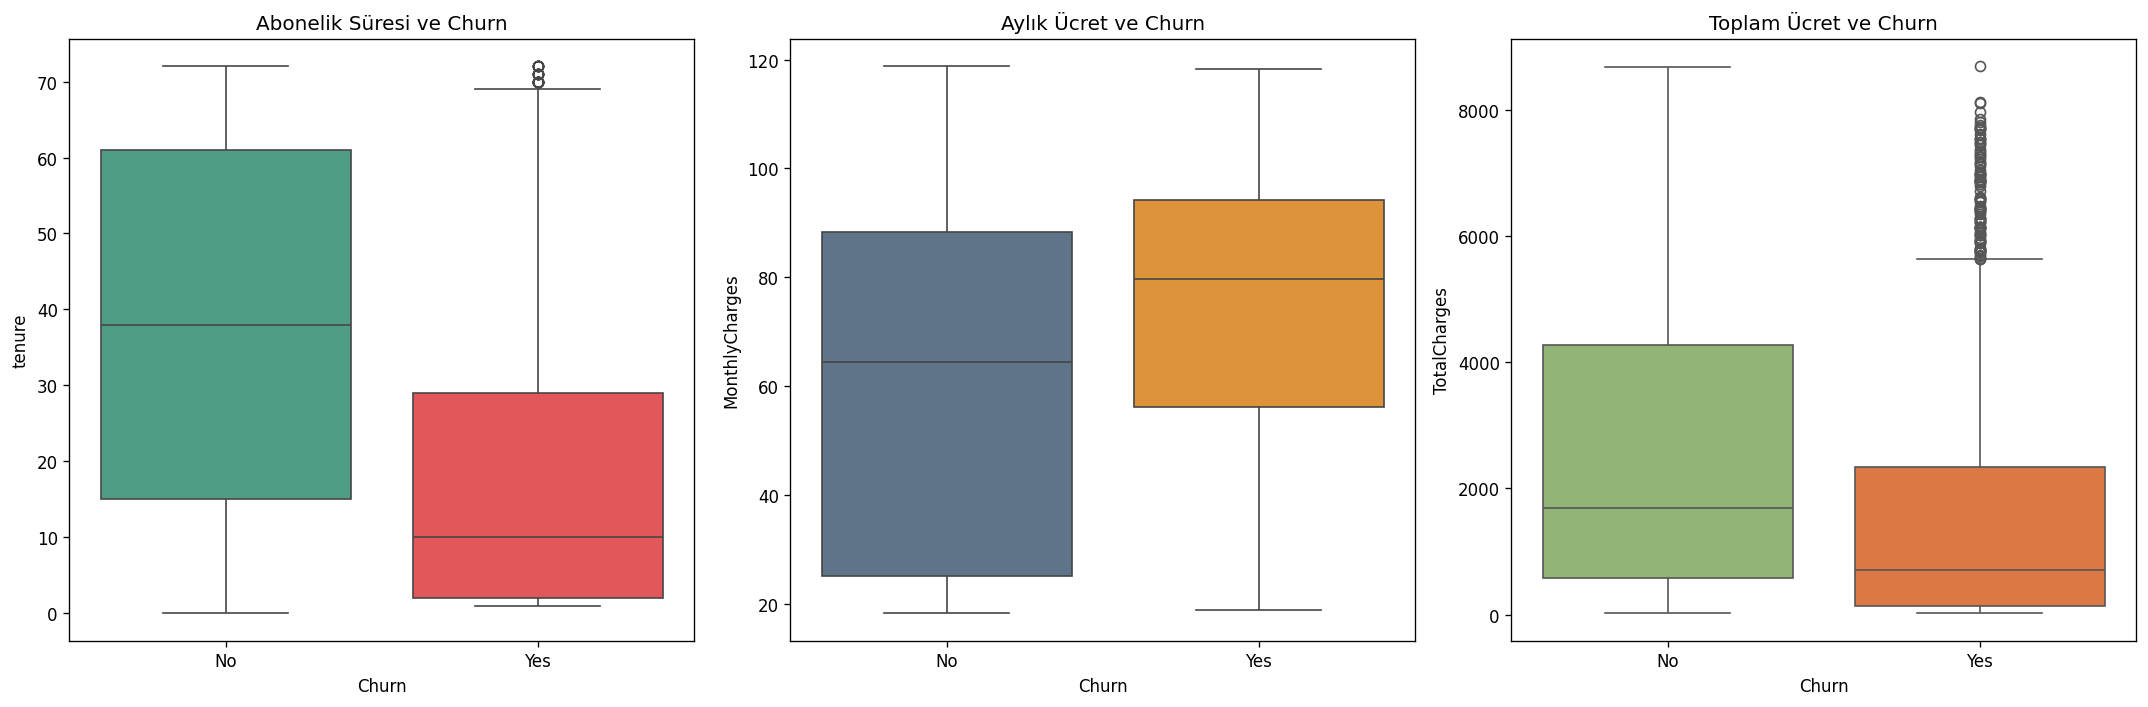

In [13]:
# EDA -  Sayısal değişken kutu grafikleri
plt.figure(figsize=(18, 6), dpi=120)

plt.subplot(1, 3, 1)
sns.boxplot(data=df_eda, x='Churn', y='tenure', palette={'No': '#43aa8b', 'Yes': '#f94144'})
plt.title('Abonelik Süresi ve Churn')

plt.subplot(1, 3, 2)
sns.boxplot(data=df_eda, x='Churn', y='MonthlyCharges', palette={'No': '#577590', 'Yes': '#f8961e'})
plt.title('Aylık Ücret ve Churn')

plt.subplot(1, 3, 3)
sns.boxplot(data=df_eda, x='Churn', y='TotalCharges', palette={'No': '#90be6d', 'Yes': '#f3722c'})
plt.title('Toplam Ücret ve Churn')

plt.tight_layout()
plt.show()

In [14]:
# EDA -  Sayısal değişkenlerin korelasyonu
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
print("Sayısal değişkenlerin korelasyon matrisi:")
print(df_eda[numeric_cols].corr())

Sayısal değişkenlerin korelasyon matrisi:
                  tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure          1.000000        0.247900      0.825464       0.016567
MonthlyCharges  0.247900        1.000000      0.650864       0.220173
TotalCharges    0.825464        0.650864      1.000000       0.102652
SeniorCitizen   0.016567        0.220173      0.102652       1.000000


=== EDA 3A: KATEGORİK DEĞİŞKENLERİN CHURN İLE İLİŞKİSİ (1. GRUP) ===


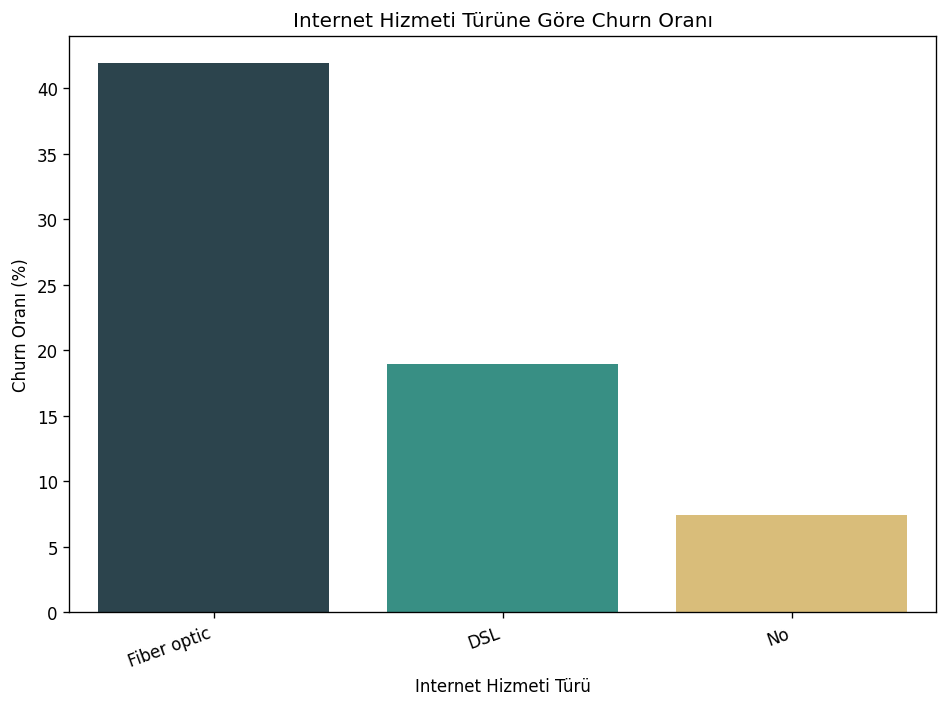

In [15]:
# EDA -  Kategorik Değişkenlerin Churn ile İlişkisi
print("=== EDA 3A: KATEGORİK DEĞİŞKENLERİN CHURN İLE İLİŞKİSİ (1. GRUP) ===")

feature = 'InternetService'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#264653', '#2a9d8f', '#e9c46a'],
    legend=False
)
plt.title('Internet Hizmeti Türüne Göre Churn Oranı')
plt.xlabel('Internet Hizmeti Türü')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

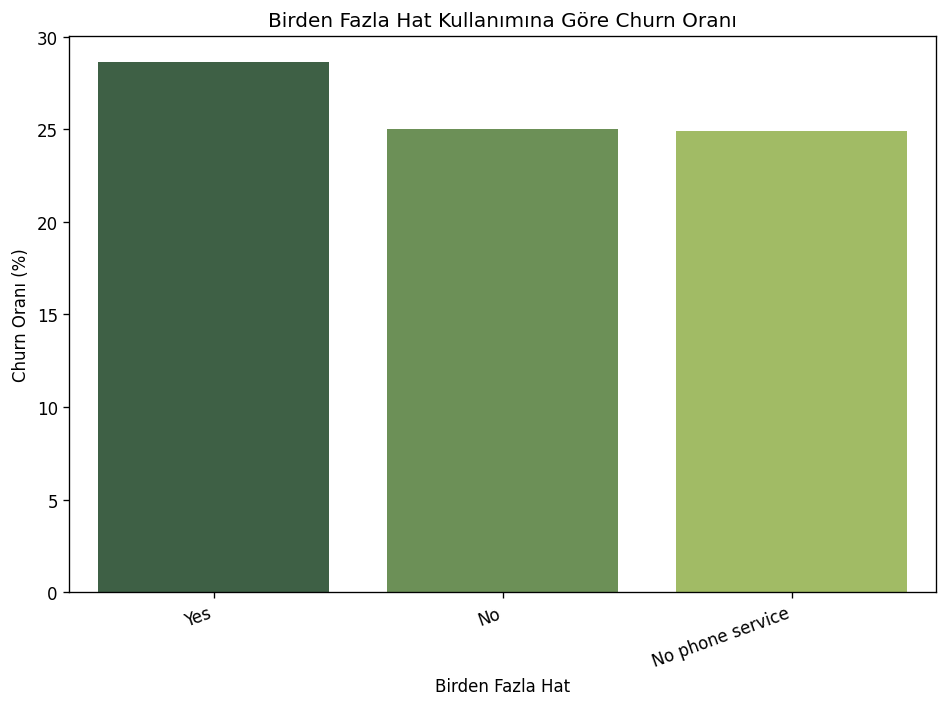

In [16]:
# EDA -  MultipleLines için churn oranı
feature = 'MultipleLines'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#386641', '#6a994e', '#a7c957'],
    legend=False
)
plt.title('Birden Fazla Hat Kullanımına Göre Churn Oranı')
plt.xlabel('Birden Fazla Hat')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

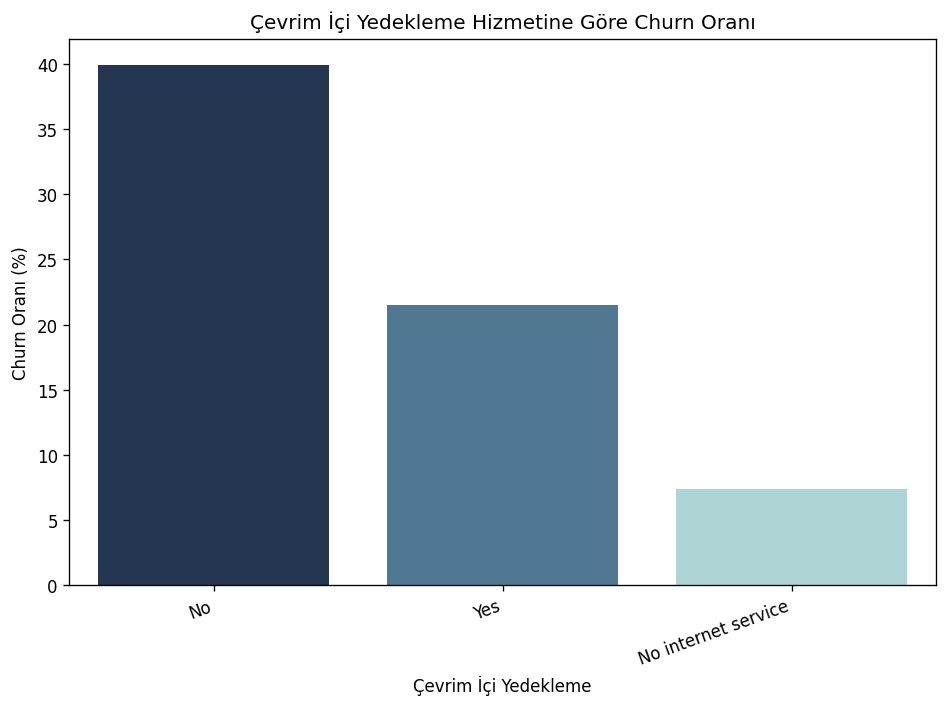

In [17]:
# EDA -  OnlineBackup için churn oranı
feature = 'OnlineBackup'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#1d3557', '#457b9d', '#a8dadc'],
    legend=False
)
plt.title('Çevrim İçi Yedekleme Hizmetine Göre Churn Oranı')
plt.xlabel('Çevrim İçi Yedekleme')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

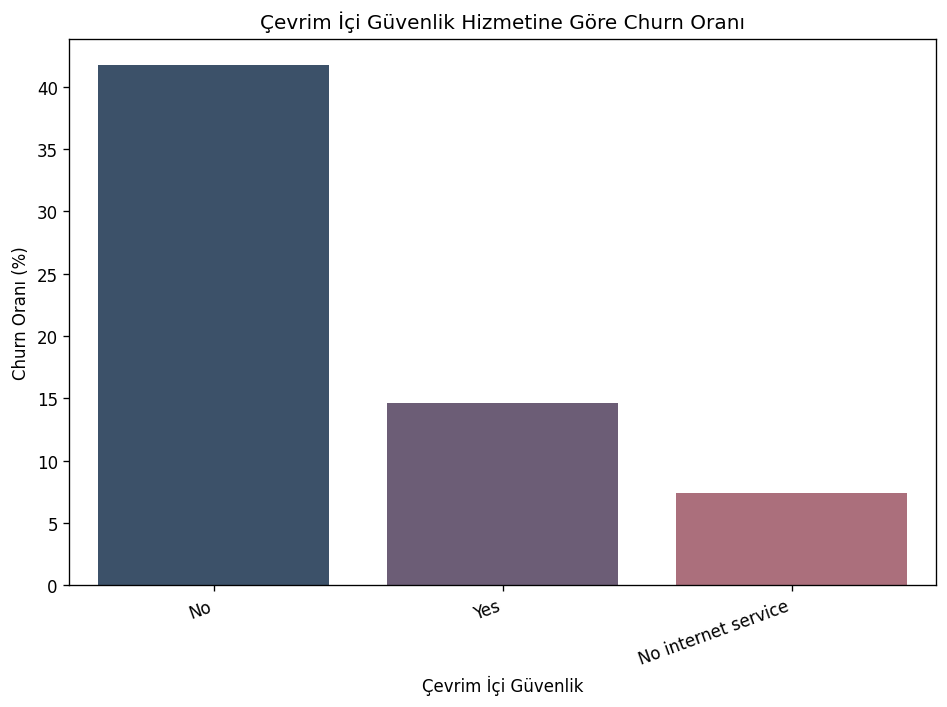

In [18]:
# EDA -  OnlineSecurity için churn oranı
feature = 'OnlineSecurity'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#355070', '#6d597a', '#b56576'],
    legend=False
)
plt.title('Çevrim İçi Güvenlik Hizmetine Göre Churn Oranı')
plt.xlabel('Çevrim İçi Güvenlik')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

=== EDA 4A: KATEGORİK DEĞİŞKENLERİN CHURN İLE İLİŞKİSİ (2. GRUP) ===


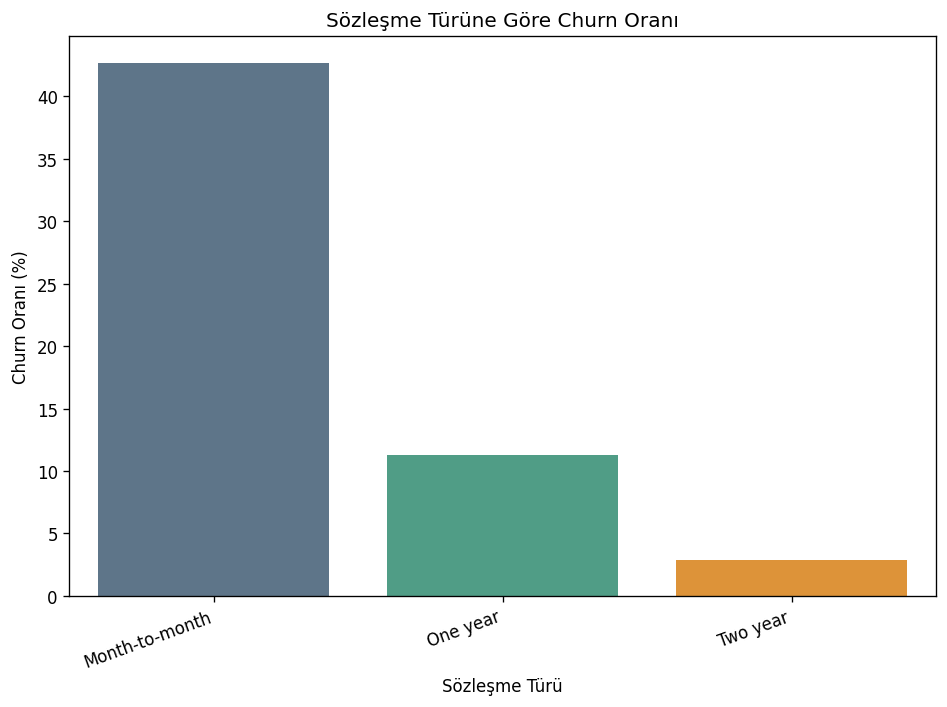

In [19]:
# EDA -  Kategorik Değişkenlerin Churn ile İlişkisi (2. Grup)
print("=== EDA 4A: KATEGORİK DEĞİŞKENLERİN CHURN İLE İLİŞKİSİ (2. GRUP) ===")

feature = 'Contract'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#577590', '#43aa8b', '#f8961e'],
    legend=False
)
plt.title('Sözleşme Türüne Göre Churn Oranı')
plt.xlabel('Sözleşme Türü')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

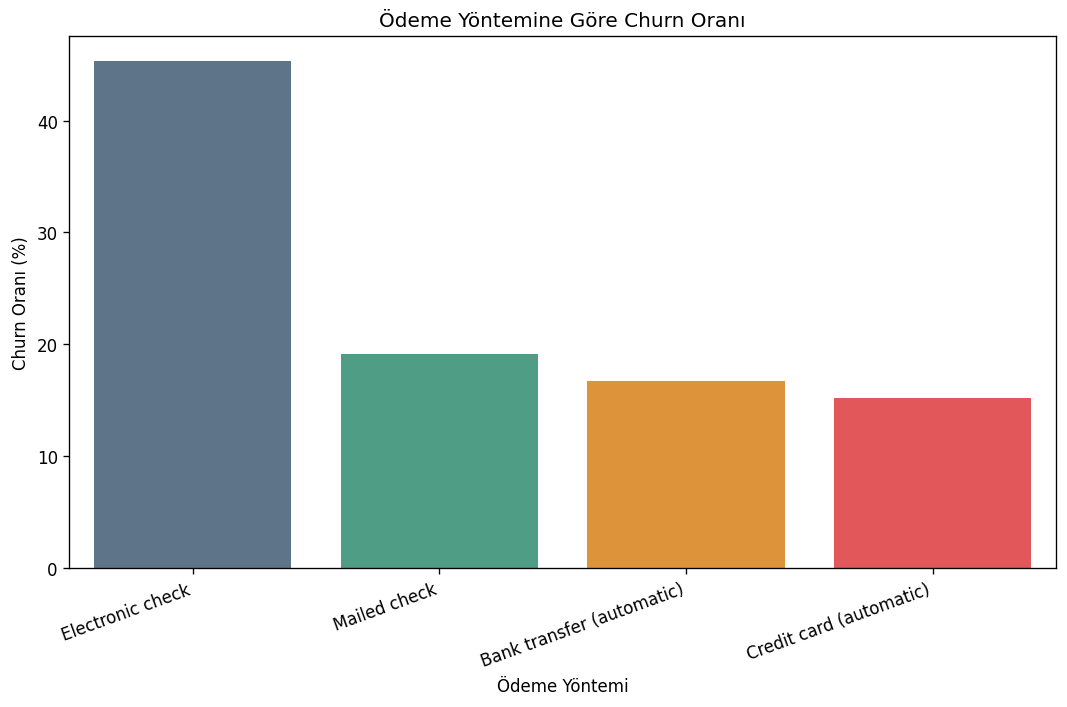

In [20]:
# EDA -  PaymentMethod için churn oranı
feature = 'PaymentMethod'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(9, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#577590', '#43aa8b', '#f8961e', '#f94144'],
    legend=False
)
plt.title('Ödeme Yöntemine Göre Churn Oranı')
plt.xlabel('Ödeme Yöntemi')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

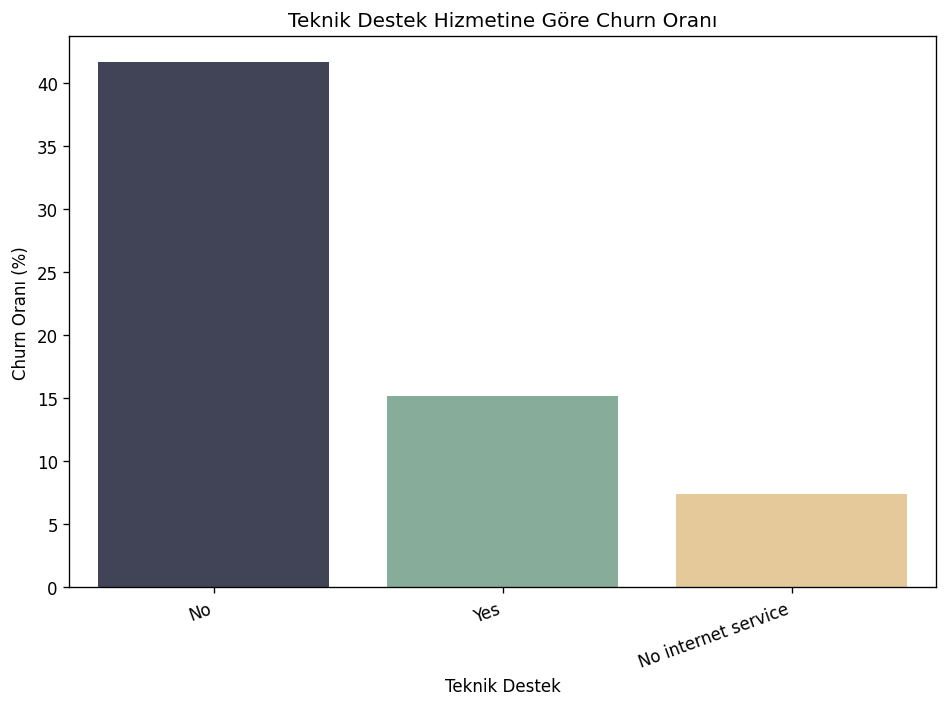

In [21]:
# EDA -  TechSupport için churn oranı
feature = 'TechSupport'
churn_rate_by_feature = (
    df_eda.groupby(feature)['Churn']
    .apply(lambda series: (series == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .reset_index(name='ChurnRate')
)

plt.figure(figsize=(8, 6), dpi=120)
sns.barplot(
    data=churn_rate_by_feature,
    x=feature,
    y='ChurnRate',
    hue=feature,
    palette=['#3d405b', '#81b29a', '#f2cc8f'],
    legend=False
)
plt.title('Teknik Destek Hizmetine Göre Churn Oranı')
plt.xlabel('Teknik Destek')
plt.ylabel('Churn Oranı (%)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

=== EDA 5: KORELASYON ANALİZİ ===


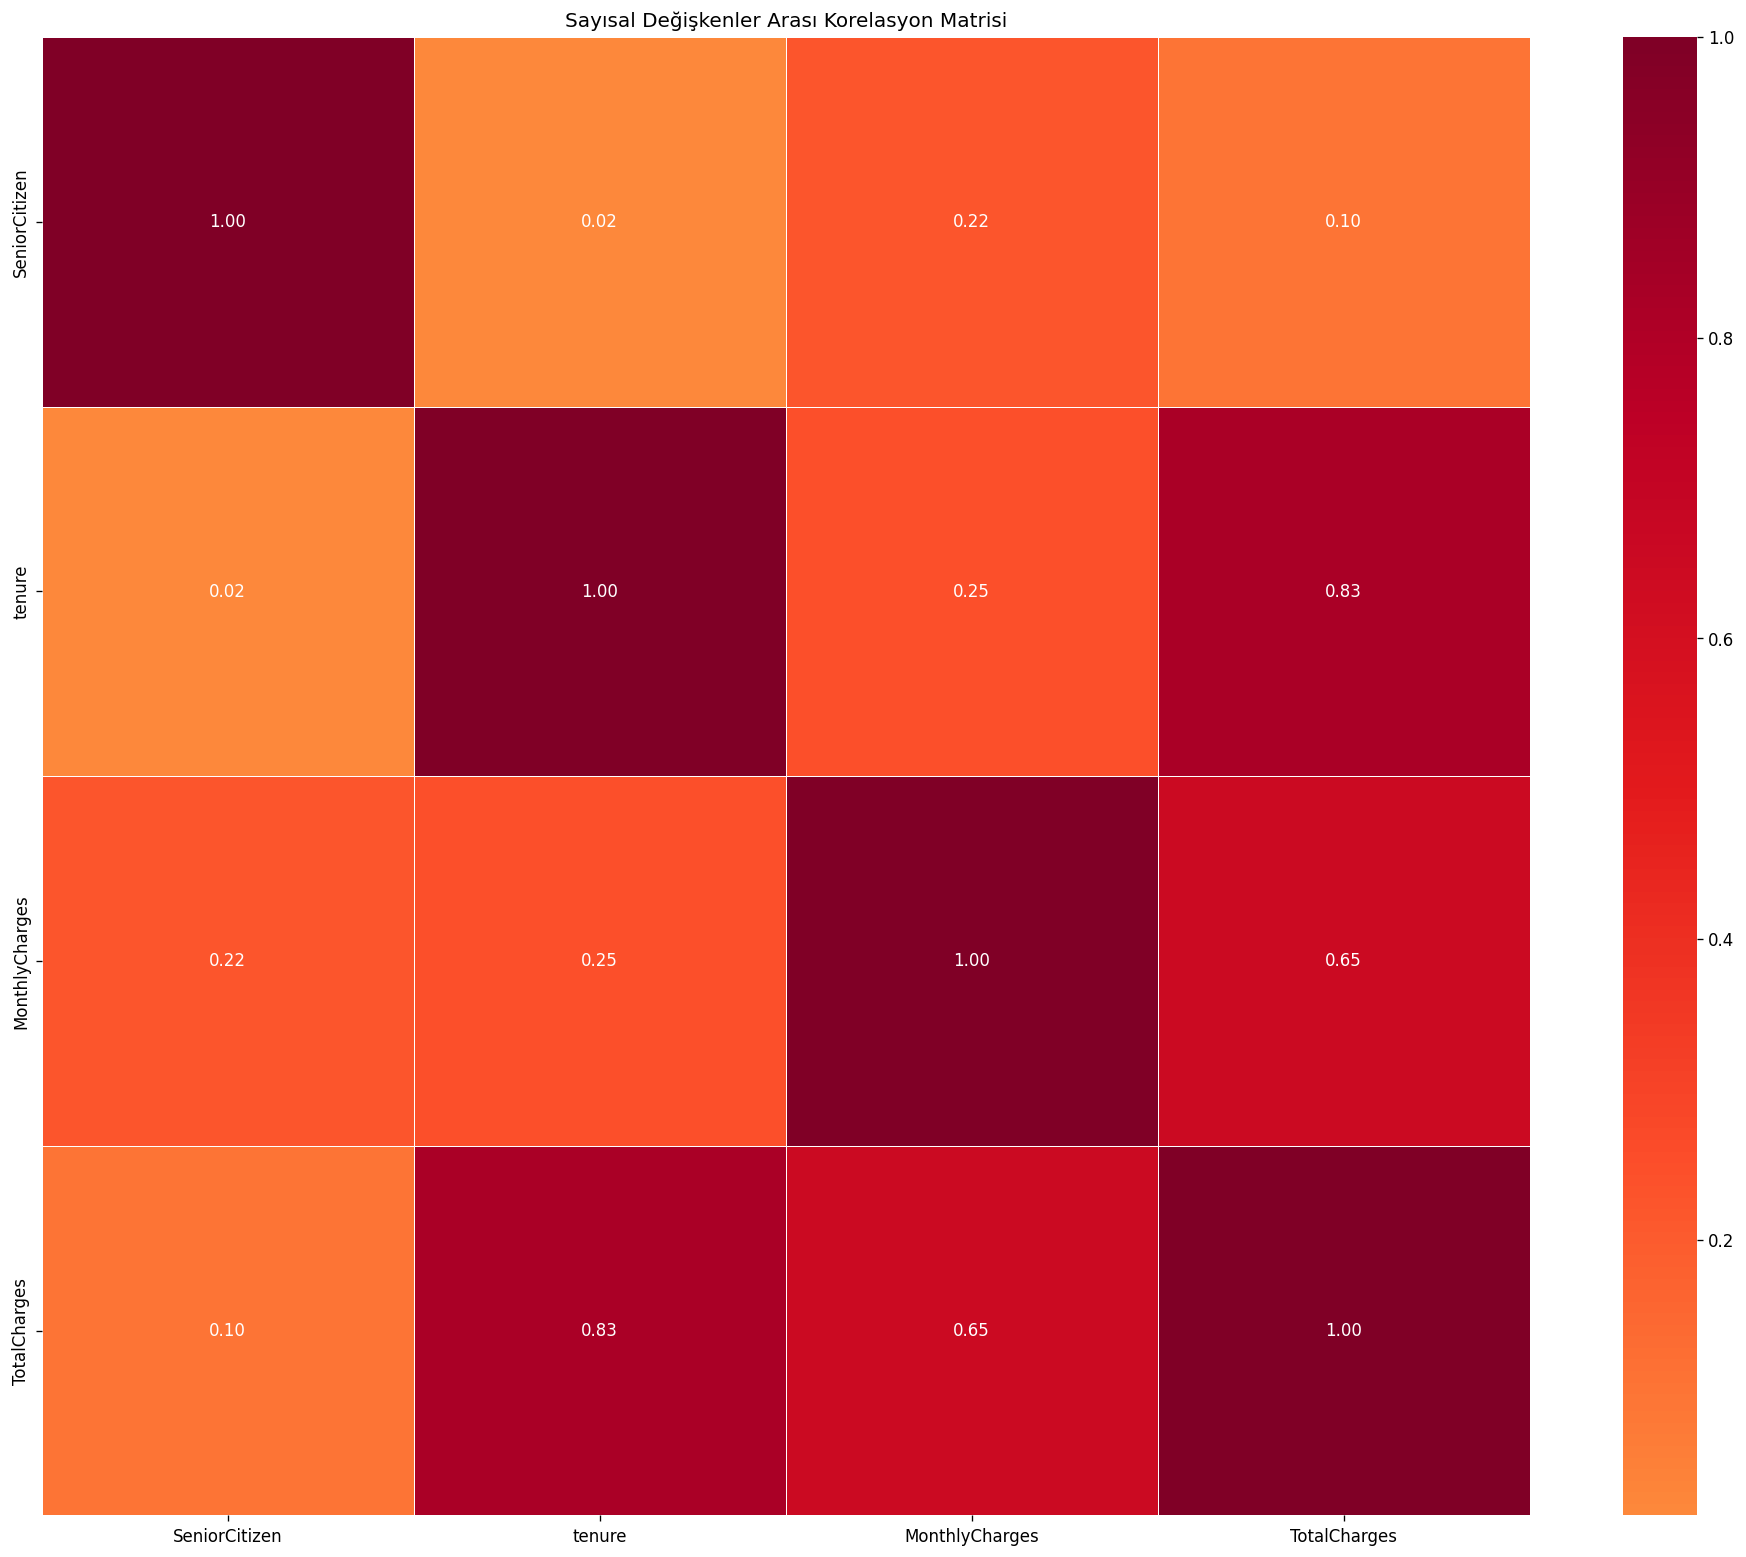

In [22]:
# EDA -  Korelasyon ısı haritası
print("=== EDA 5: KORELASYON ANALİZİ ===")

plt.figure(figsize=(20, 16), dpi=120)
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
correlation_matrix = df_eda[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd', center=0, fmt='.2f', linewidths=0.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

# Churn'u encode edelim
df_eda['Churn_encoded'] = df_eda['Churn'].map({'Yes': 1, 'No': 0})
all_numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
churn_corr = df_eda[all_numeric_cols].corr()['Churn_encoded'].abs().sort_values(ascending=False)

In [23]:
# EDA -  Korelasyon tablosu
correlation_table = correlation_matrix.round(2)
print("\nKorelasyon tablosu:")
print(correlation_table)


Korelasyon tablosu:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


In [24]:
# EDA -  Churn ile korelasyon tablosu
print("\nChurn ile korelasyon (mutlak değer):")
print(churn_corr[1:11])


Churn ile korelasyon (mutlak değer):
tenure            0.352229
TotalCharges      0.199037
MonthlyCharges    0.193356
SeniorCitizen     0.150889
Name: Churn_encoded, dtype: float64


In [25]:
# Veri Kontrolü ve Normalizasyon 
print("=== VERİ KONTROLÜ VE NORMALİZASYON (EDA SONRASI) ===")

# Boş değer kontrolü
missing_values_eda = df_eda.isnull().sum()
print("Eksik değerler (EDA verisi):")
print(missing_values_eda[missing_values_eda > 0])

# Normalizasyon kontrolü 
numeric_cols_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler_eda = StandardScaler()
df_eda_scaled = df_eda.copy()
df_eda_scaled[numeric_cols_eda] = scaler_eda.fit_transform(df_eda[numeric_cols_eda])

print("EDA sonrası sayısal değişkenler standardize edildi.")
print(f"Ölçeklendirilmiş veri örneği:\n{df_eda_scaled[numeric_cols_eda].head()}")

=== VERİ KONTROLÜ VE NORMALİZASYON (EDA SONRASI) ===
Eksik değerler (EDA verisi):
Series([], dtype: int64)
EDA sonrası sayısal değişkenler standardize edildi.
Ölçeklendirilmiş veri örneği:
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.994242
1  0.066327       -0.259629     -0.173244
2 -1.236724       -0.362660     -0.959674
3  0.514251       -0.746535     -0.194766
4 -1.236724        0.197365     -0.940470


## 3. Özellik Mühendisliği

In [26]:
# Özellik Mühendisliği
print("=== ÖZELLİK MÜHENDİSLİĞİ ===")

# Temizlenmiş veriyi kullanacağız
df_features = df_clean.copy()

# 1. Yeni özellikler oluşturalım
# Tenure kategorileri
df_features['tenure_group'] = pd.cut(df_features['tenure'],
                                   bins=[0, 12, 24, 48, 72],
                                   labels=['0-1_year', '1-2_years', '2-4_years', '4+_years'])

# Aylık ücret kategorileri
df_features['monthly_charges_group'] = pd.cut(df_features['MonthlyCharges'],
                                            bins=[0, 35, 65, 90, 120],
                                            labels=['Low', 'Medium', 'High', 'Very_High'])

# Hizmet sayısı
service_cols = ['PhoneService', 'MultipleLines_Yes', 'InternetService_Fiber optic',
               'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
               'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df_features['total_services'] = df_features[service_cols].sum(axis=1)

# Ekstra hizmet sayısı
extra_services = ['OnlineSecurity_Yes', 'OnlineBackup_Yes', 'DeviceProtection_Yes',
                 'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']
df_features['extra_services'] = df_features[extra_services].sum(axis=1)

# Müşteri değeri hesaplaması
df_features['customer_value'] = df_features['TotalCharges'] / (df_features['tenure'] + 1)

# Churn risk skoru (basit hesap)
df_features['churn_risk_score'] = (
    (df_features['MonthlyCharges'] > df_features['MonthlyCharges'].median()) * 1 +
    (df_features['tenure'] < df_features['tenure'].median()) * 1 +
    (df_features['Contract_Two year'] == 0) * 1 +
    (df_features['PaymentMethod_Electronic check'] == 1) * 1
)

# Kategorik özellikleri one-hot encode edelim
categorical_new = ['tenure_group', 'monthly_charges_group']
df_features = pd.get_dummies(df_features, columns=categorical_new, drop_first=True)

print(f"Özellik mühendisliği sonrası veri boyutu: {df_features.shape}")
print("\nYeni oluşturulan özellikler:")
new_features = ['total_services', 'extra_services', 'customer_value', 'churn_risk_score']
print(new_features)

# Özellik seçimi - korelasyon tabanlı
X_temp = df_features.drop('Churn', axis=1)
y_temp = df_features['Churn']

# En iyi özellikleri seçelim
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_temp, y_temp)
selected_features = X_temp.columns[selector.get_support()].tolist()

print(f"\nSeçilen en iyi 15 özellik: {selected_features}")

# Seçilen özellikleri kullanarak devam edelim
df_selected = df_features[selected_features + ['Churn']]
print(f"Seçilen özelliklerle veri boyutu: {df_selected.shape}")

df_features.head()

=== ÖZELLİK MÜHENDİSLİĞİ ===
Özellik mühendisliği sonrası veri boyutu: (7021, 41)

Yeni oluşturulan özellikler:
['total_services', 'extra_services', 'customer_value', 'churn_risk_score']

Seçilen en iyi 15 özellik: ['tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_Two year', 'PaymentMethod_Electronic check', 'churn_risk_score', 'tenure_group_4+_years']
Seçilen özelliklerle veri boyutu: (7021, 16)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,total_services,extra_services,customer_value,churn_risk_score,tenure_group_1-2_years,tenure_group_2-4_years,tenure_group_4+_years,monthly_charges_group_Medium,monthly_charges_group_High,monthly_charges_group_Very_High
0,0,0,1,0,1,0,1,29.85,29.85,0,...,1,1,14.925000,3,False,False,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,3,2,53.985714,1,False,True,False,True,False,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,3,2,36.050000,2,False,False,False,True,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,3,3,40.016304,1,False,True,False,True,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,2,0,50.550000,4,False,False,False,False,True,False


## 4. Veri Hazırlığı ve Ayrı Ayrı Normalizasyon

In [27]:
# Veri Kontrolü ve Normalizasyon 
print("=== VERİ HAZIRLIĞI VE NORMALİZASYON (MODELLEME ÖNCESİ) ===")

# Boş değer kontrolü
missing_values_norm = df_selected.isnull().sum()
print("Eksik değerler (normalizasyon verisi):")
print(missing_values_norm[missing_values_norm > 0])

# Veri tipi kontrolü
print(f"\nVeri tipleri: {df_selected.dtypes}")

# Aykırı değer kontrolü
numeric_cols_norm = df_selected.select_dtypes(include=[np.number]).columns
print("\nAykırı değer kontrolü (IQR yöntemi):")
for col in numeric_cols_norm:
    if col != 'Churn':
        Q1 = df_selected[col].quantile(0.25)
        Q3 = df_selected[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = ((df_selected[col] < (Q1 - 1.5 * IQR)) | (df_selected[col] > (Q3 + 1.5 * IQR))).sum()
        print(f"{col}: {outliers} aykırı değer")

print("Normalizasyon kısmına geçiliyor...")

=== VERİ HAZIRLIĞI VE NORMALİZASYON (MODELLEME ÖNCESİ) ===
Eksik değerler (normalizasyon verisi):
Series([], dtype: int64)

Veri tipleri: tenure                                    int64
MonthlyCharges                          float64
TotalCharges                            float64
InternetService_Fiber optic                bool
InternetService_No                         bool
OnlineSecurity_No internet service         bool
OnlineBackup_No internet service           bool
DeviceProtection_No internet service       bool
TechSupport_No internet service            bool
StreamingTV_No internet service            bool
StreamingMovies_No internet service        bool
Contract_Two year                          bool
PaymentMethod_Electronic check             bool
churn_risk_score                          int64
tenure_group_4+_years                      bool
Churn                                     int64
dtype: object

Aykırı değer kontrolü (IQR yöntemi):
tenure: 0 aykırı değer
MonthlyCharges: 0 a

In [28]:
# Farklı Normalizasyon Yöntemleri
print("=== VERİ HAZIRLIĞI VE NORMALİZASYON ===")

X = df_selected.drop('Churn', axis=1)
y = df_selected['Churn']

X_train_base, X_test_base, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

normalization_results = {}
print("Farklı normalizasyon yöntemleri test ediliyor...")

for scaler_name, scaler in scalers.items():
    print(f"\n{scaler_name} uygulanıyor...")
    X_train_scaled = scaler.fit_transform(X_train_base)
    X_test_scaled = scaler.transform(X_test_base)

    test_models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42),
        'SVM': SVC(random_state=42)
    }

    scaler_results = {}
    for model_name, model in test_models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        scaler_results[model_name] = accuracy
        print(f"  {model_name}: {accuracy:.4f}")

    normalization_results[scaler_name] = scaler_results

print("\n" + "="*60)
print("NORMALİZASYON YÖNTEMLERİ KARŞILAŞTIRMASI")
print("="*60)

norm_df = pd.DataFrame(normalization_results).T
print(norm_df.round(4))

best_scaler_name = norm_df.mean(axis=1).idxmax()
best_scaler = scalers[best_scaler_name]
print(f"\nEn iyi normalizasyon yöntemi: {best_scaler_name}")

print("\nSMOTE ile veri dengeleme uygulanıyor...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_base, y_train)

print(f"Orijinal eğitim verisi: {X_train_base.shape}, {y_train.value_counts().to_dict()}")
print(f"SMOTE sonrası eğitim verisi: {X_train_smote.shape}, {pd.Series(y_train_smote).value_counts().to_dict()}")

X_train_final = best_scaler.fit_transform(X_train_smote)
X_test_final = best_scaler.transform(X_test_base)

print("\nSMOTE + Normalizasyon ile final model eğitimi...")
final_model = RandomForestClassifier(random_state=42, n_estimators=100)
final_model.fit(X_train_final, y_train_smote)
y_pred_final = final_model.predict(X_test_final)

print("Final Model Sonuçları:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final)

=== VERİ HAZIRLIĞI VE NORMALİZASYON ===
Farklı normalizasyon yöntemleri test ediliyor...

StandardScaler uygulanıyor...
  Logistic Regression: 0.7936
  Random Forest: 0.7680
  SVM: 0.7936

MinMaxScaler uygulanıyor...
  Logistic Regression: 0.7915
  Random Forest: 0.7658
  SVM: 0.7879

RobustScaler uygulanıyor...
  Logistic Regression: 0.7936
  Random Forest: 0.7673
  SVM: 0.7915

NORMALİZASYON YÖNTEMLERİ KARŞILAŞTIRMASI
                Logistic Regression  Random Forest     SVM
StandardScaler               0.7936         0.7680  0.7936
MinMaxScaler                 0.7915         0.7658  0.7879
RobustScaler                 0.7936         0.7673  0.7915

En iyi normalizasyon yöntemi: StandardScaler

SMOTE ile veri dengeleme uygulanıyor...
Orijinal eğitim verisi: (5616, 15), {0: 4131, 1: 1485}
SMOTE sonrası eğitim verisi: (8262, 15), {1: 4131, 0: 4131}

SMOTE + Normalizasyon ile final model eğitimi...
Final Model Sonuçları:
Accuracy: 0.7466
              precision    recall  f1-score   su

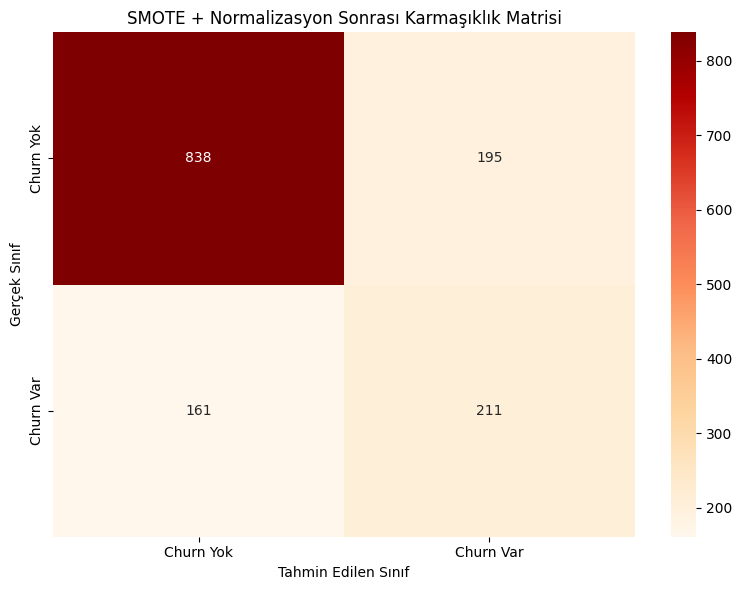

In [29]:
# SMOTE + Normalizasyon - Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='OrRd',
    xticklabels=['Churn Yok', 'Churn Var'],
    yticklabels=['Churn Yok', 'Churn Var']
)
plt.title('SMOTE + Normalizasyon Sonrası Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.tight_layout()
plt.show()

In [30]:
# Normalizasyon karşılaştırması 
print("\nNormalizasyon tablo özeti:")
print(norm_df.round(4))


Normalizasyon tablo özeti:
                Logistic Regression  Random Forest     SVM
StandardScaler               0.7936         0.7680  0.7936
MinMaxScaler                 0.7915         0.7658  0.7879
RobustScaler                 0.7936         0.7673  0.7915


## 5. PCA ile Özellik Çıkarımı

In [31]:
# PCA ile Özellik Çıkarımı 
print("=== PCA ILE OZELLIK CIKARIMI ===")

missing_values_dl = df_selected.isnull().sum()
print("Eksik değerler (özellik çıkarımı verisi):")
print(missing_values_dl[missing_values_dl > 0])

print(f"\nVeri boyutu: {df_selected.shape}")
print("Hedef sınıf dağılımı:")
print(df_selected['Churn'].value_counts())
print(f"Churn oranı: {df_selected['Churn'].mean():.3f}")

=== PCA ILE OZELLIK CIKARIMI ===
Eksik değerler (özellik çıkarımı verisi):
Series([], dtype: int64)

Veri boyutu: (7021, 16)
Hedef sınıf dağılımı:
Churn
0    5164
1    1857
Name: count, dtype: int64
Churn oranı: 0.264


=== PCA TABANLI OZELLIK CIKARIMI VE MODELLEME ===
İlk 5 bileşen ile açıklanan toplam varyans: 0.972

PCA bileşen özeti:


,Bileşen,Açıklanan Varyans,Kümülatif Varyans
0,PC1,0.565321,0.565321
1,PC2,0.235726,0.801047
2,PC3,0.089673,0.890720
3,PC4,0.047170,0.937890
4,PC5,0.034020,0.971911



PCA sonrası Random Forest doğruluğu: 0.7737
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.58      0.50      0.54       372

    accuracy                           0.77      1405
   macro avg       0.71      0.69      0.70      1405
weighted avg       0.76      0.77      0.77      1405



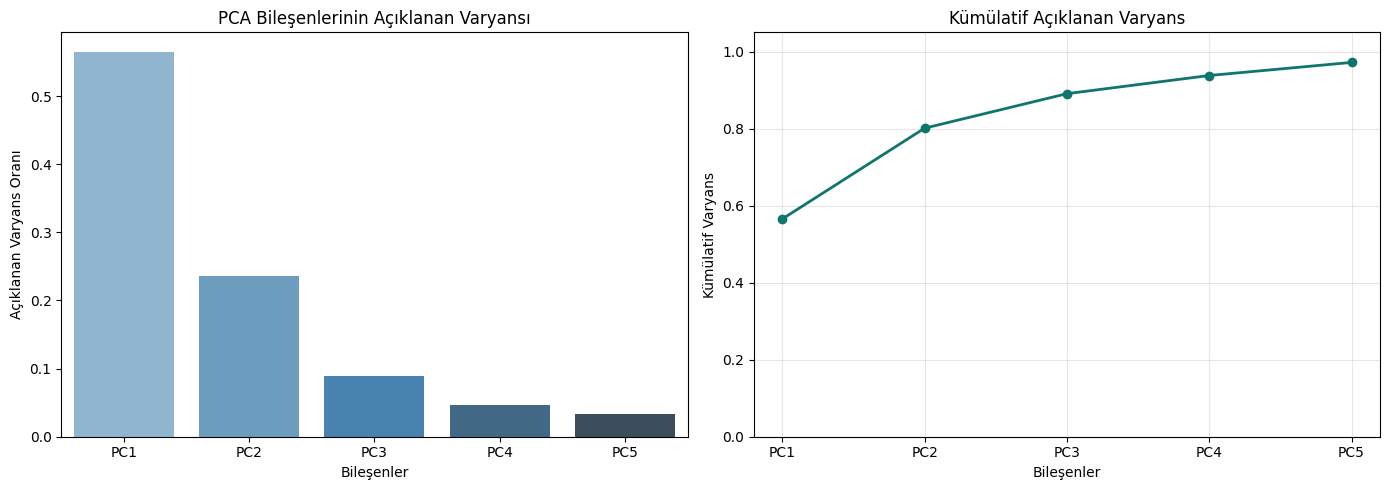

In [32]:
# PCA ile Özellik Çıkarımı ve Modelleme
print("=== PCA TABANLI OZELLIK CIKARIMI VE MODELLEME ===")

X_dl = df_selected.drop('Churn', axis=1)
y_dl = df_selected['Churn']

scaler_dl = StandardScaler()
X_dl_scaled = scaler_dl.fit_transform(X_dl)

pca_dl = PCA(n_components=5)
X_pca = pca_dl.fit_transform(X_dl_scaled)

feature_importance_pca = pca_dl.explained_variance_ratio_
print(f"İlk 5 bileşen ile açıklanan toplam varyans: {feature_importance_pca.sum():.3f}")

pca_summary_df = pd.DataFrame({
    'Bileşen': [f'PC{i+1}' for i in range(len(feature_importance_pca))],
    'Açıklanan Varyans': feature_importance_pca,
    'Kümülatif Varyans': np.cumsum(feature_importance_pca)
})
print("\nPCA bileşen özeti:")
display(pca_summary_df)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pca,
    y_dl,
    test_size=0.2,
    random_state=42,
    stratify=y_dl
)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_dl, y_train_dl)
y_pred_pca = rf_pca.predict(X_test_dl)

accuracy = accuracy_score(y_test_dl, y_pred_pca)
print(f"\nPCA sonrası Random Forest doğruluğu: {accuracy:.4f}")
print("Sınıflandırma Raporu:")
print(classification_report(y_test_dl, y_pred_pca))

_, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=pca_summary_df,
    x='Bileşen',
    y='Açıklanan Varyans',
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('PCA Bileşenlerinin Açıklanan Varyansı')
axes[0].set_ylabel('Açıklanan Varyans Oranı')
axes[0].set_xlabel('Bileşenler')

axes[1].plot(
    pca_summary_df['Bileşen'],
    pca_summary_df['Kümülatif Varyans'],
    marker='o',
    color='#0f766e',
    linewidth=2
)
axes[1].set_title('Kümülatif Açıklanan Varyans')
axes[1].set_ylabel('Kümülatif Varyans')
axes[1].set_xlabel('Bileşenler')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Modelleme ve Sınıflandırma Algoritmaları

In [33]:
# Modelleme Öncesi Veri Özeti
print("=== MODELLEME ÖNCESİ VERİ ÖZETİ ===")

missing_values_model = df_selected.isnull().sum()
print("Eksik değerler (modelleme verisi):")
print(missing_values_model[missing_values_model > 0])

print(f"\nSınıf dağılımı: {df_selected['Churn'].value_counts().to_dict()}")
print(f"Churn oranı: {df_selected['Churn'].mean():.3f}")
print(f"Modelleme için kullanılacak veri boyutu: {df_selected.shape}")
print("Not: Ölçeklendirme, aşağıdaki model hazırlık hücresinde yalnızca gereken modeller için uygulanır.")

=== MODELLEME ÖNCESİ VERİ ÖZETİ ===
Eksik değerler (modelleme verisi):
Series([], dtype: int64)

Sınıf dağılımı: {0: 5164, 1: 1857}
Churn oranı: 0.264
Modelleme için kullanılacak veri boyutu: (7021, 16)
Not: Ölçeklendirme, aşağıdaki model hazırlık hücresinde yalnızca gereken modeller için uygulanır.


In [34]:
# Kapsamlı Model Eğitimi - Hazırlık ve Değerlendirme Altyapısı
print("=== MODELLEME VE SINIFLANDIRMA ALGORİTMALARI ===")

# Seçilen özellikleri kullanacağız
X = df_selected.drop('Churn', axis=1)
y = df_selected['Churn']

# Eğitim ve test verilerini ayıralım
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Ölçeklendirme (ölçek hassasiyeti olan modeller için)
scaler_main = StandardScaler()
X_train_scaled = scaler_main.fit_transform(X_train)
X_test_scaled = scaler_main.transform(X_test)

results = {}

def evaluate_and_store_model(model_name, model, use_scaled_data=False):
    """Tek bir modeli eğitir, metrikleri hesaplar ve results sözlüğüne kaydeder."""
    train_input = X_train_scaled if use_scaled_data else X_train
    test_input = X_test_scaled if use_scaled_data else X_test

    print("\n" + "=" * 70)
    print(f"MODEL: {model_name}")
    print("=" * 70)
    print(f"Ölçeklendirilmiş veri kullanımı: {'Evet' if use_scaled_data else 'Hayır'}")

    cv_scores = cross_val_score(model, train_input, y_train, cv=5, scoring='accuracy')
    print(f"5-Fold CV Accuracy Ortalama: {cv_scores.mean():.4f}")
    print(f"5-Fold CV Accuracy Std: {cv_scores.std():.4f}")

    model.fit(train_input, y_train)
    y_pred = model.predict(test_input)

    y_pred_proba = None
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(test_input)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    cm = confusion_matrix(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    if not np.isnan(auc):
        print(f"AUC Score: {auc:.4f}")
    else:
        print("AUC Score: hesaplanamadı (predict_proba yok)")

    print("\nSınıflandırma Raporu:")
    print(classification_report(y_test, y_pred))

    cm_df = pd.DataFrame(
        cm,
        index=['Gerçek 0', 'Gerçek 1'],
        columns=['Tahmin 0', 'Tahmin 1']
    )
    print("Karmaşıklık Matrisi:")
    print(cm_df)

    if accuracy >= 0.80:
        perf_label, perf_color = 'Çok İyi', '#2a9d8f'
    elif accuracy >= 0.75:
        perf_label, perf_color = 'İyi', '#1d84b5'
    elif accuracy >= 0.70:
        perf_label, perf_color = 'Orta', '#f4a261'
    else:
        perf_label, perf_color = 'Geliştirilmeli', '#e76f51'

    _, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4.8),
        dpi=120,
        gridspec_kw={'width_ratios': [1, 1.25]}
    )

    # Sol panel: donut doğruluk göstergesi
    axes[0].pie(
        [accuracy, 1 - accuracy],
        startangle=90,
        counterclock=False,
        colors=[perf_color, '#e9ecef'],
        wedgeprops={'width': 0.35, 'edgecolor': 'white', 'linewidth': 2}
    )
    axes[0].text(
        0,
        0.05,
        f"%{accuracy * 100:.1f}",
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold',
        color='#1f2937'
    )
    axes[0].text(
        0,
        -0.18,
        'Doğruluk',
        ha='center',
        va='center',
        fontsize=11,
        color='#374151'
    )
    axes[0].set_title(f"{model_name}\nSeviye: {perf_label}", pad=12)
    auc_text = f"AUC: {auc:.4f}" if not np.isnan(auc) else 'AUC: hesaplanamadı'
    axes[0].text(
        0,
        -1.20,
        auc_text,
        ha='center',
        va='center',
        fontsize=10,
        color='#4b5563'
    )

    # Sağ panel: yüzde + sayı birlikte gösterilen karmaşıklık matrisi
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]}\n({cm_pct[i, j] * 100:.1f}%)" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    sns.heatmap(
        cm_pct,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=1,
        cbar=True,
        square=True,
        linewidths=1.2,
        linecolor='white',
        xticklabels=['Tahmin 0', 'Tahmin 1'],
        yticklabels=['Gerçek 0', 'Gerçek 1'],
        ax=axes[1],
        cbar_kws={'shrink': 0.8, 'label': 'Sınıf İçi Oran'}
    )
    axes[1].set_title(f"{model_name} - Karmaşıklık Matrisi")
    axes[1].set_xlabel('Tahmin')
    axes[1].set_ylabel('Gerçek')

    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'model': model,
        'accuracy': accuracy,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'predictions_proba': y_pred_proba,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test, y_pred, output_dict=True)
    }

print("Model hazırlığı tamamlandı. Aşağıdaki hücrelerde modeller tek tek eğitilecektir.")

=== MODELLEME VE SINIFLANDIRMA ALGORİTMALARI ===
Model hazırlığı tamamlandı. Aşağıdaki hücrelerde modeller tek tek eğitilecektir.



MODEL: Logistic Regression
Ölçeklendirilmiş veri kullanımı: Evet
5-Fold CV Accuracy Ortalama: 0.7975
5-Fold CV Accuracy Std: 0.0017
Test Accuracy: 0.7936
AUC Score: 0.8293

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.47      0.55       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       941        92
Gerçek 1       198       174


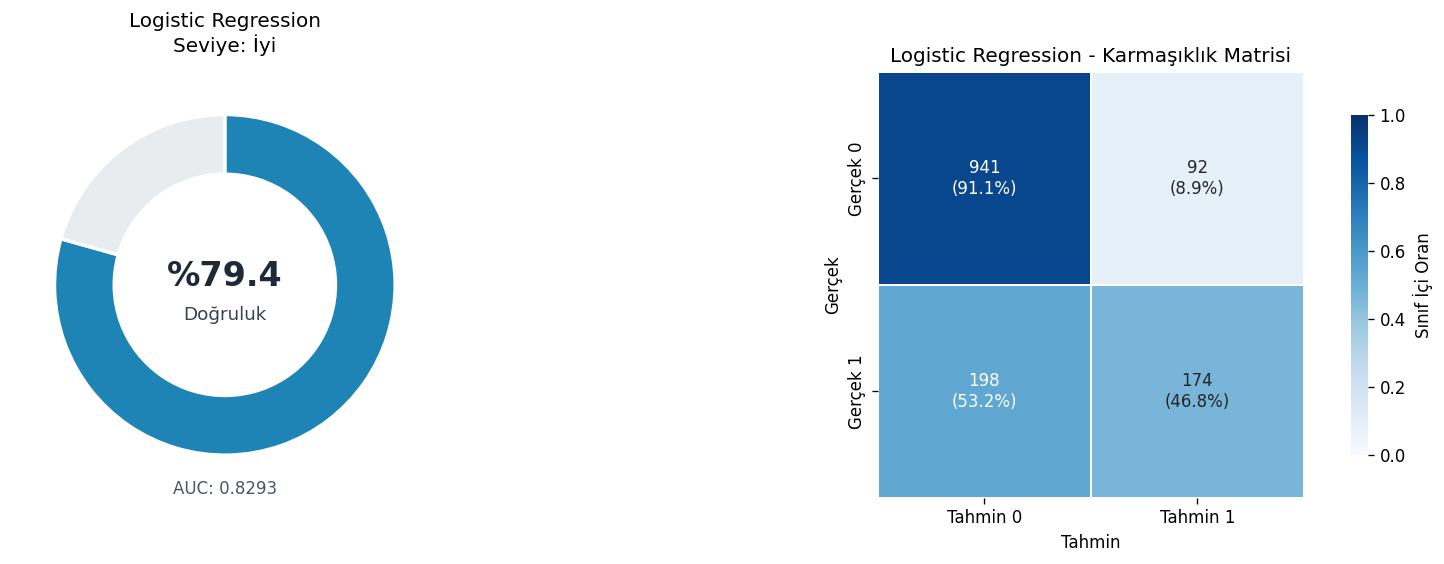

In [35]:
# Model 1 - Logistic Regression
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
evaluate_and_store_model(
    model_name='Logistic Regression',
    model=log_reg_model,
    use_scaled_data=True
)


MODEL: Random Forest
Ölçeklendirilmiş veri kullanımı: Hayır
5-Fold CV Accuracy Ortalama: 0.7644
5-Fold CV Accuracy Std: 0.0123
Test Accuracy: 0.7680
AUC Score: 0.7847

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.57      0.48      0.52       372

    accuracy                           0.77      1405
   macro avg       0.70      0.68      0.69      1405
weighted avg       0.76      0.77      0.76      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       900       133
Gerçek 1       193       179


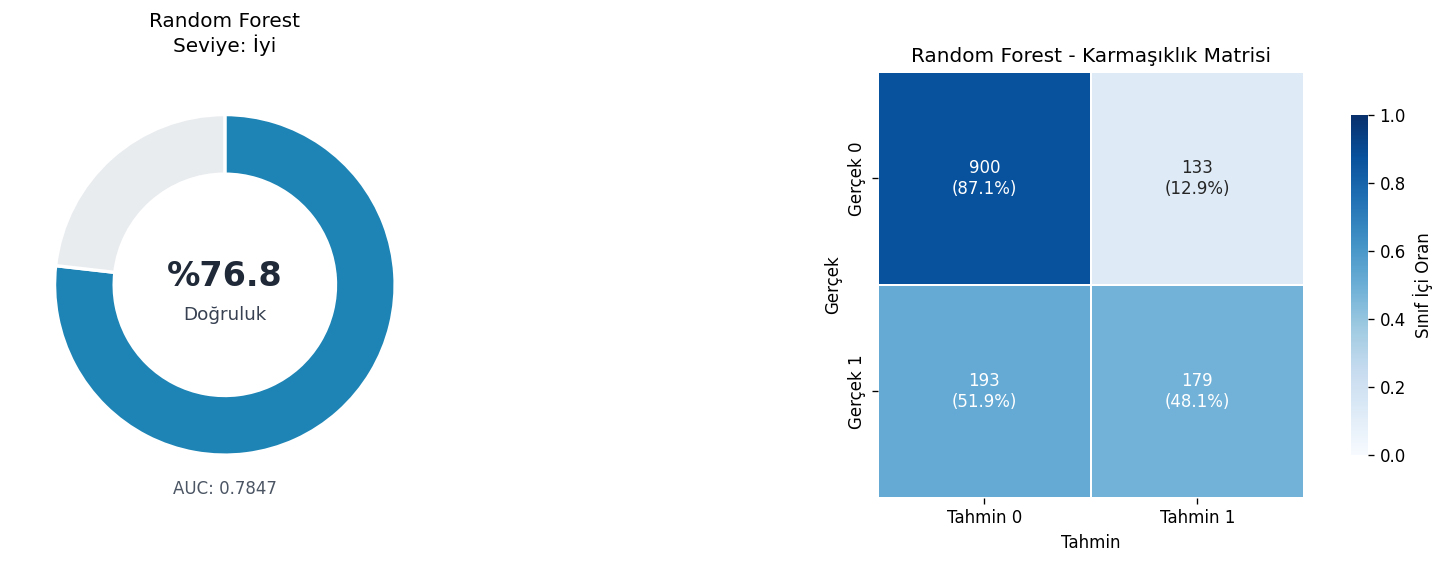

In [36]:
# Model 2 - Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
evaluate_and_store_model(
    model_name='Random Forest',
    model=rf_model,
    use_scaled_data=False
)


MODEL: SVM
Ölçeklendirilmiş veri kullanımı: Evet
5-Fold CV Accuracy Ortalama: 0.7926
5-Fold CV Accuracy Std: 0.0047
Test Accuracy: 0.7936
AUC Score: 0.7729

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.54       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       942        91
Gerçek 1       199       173


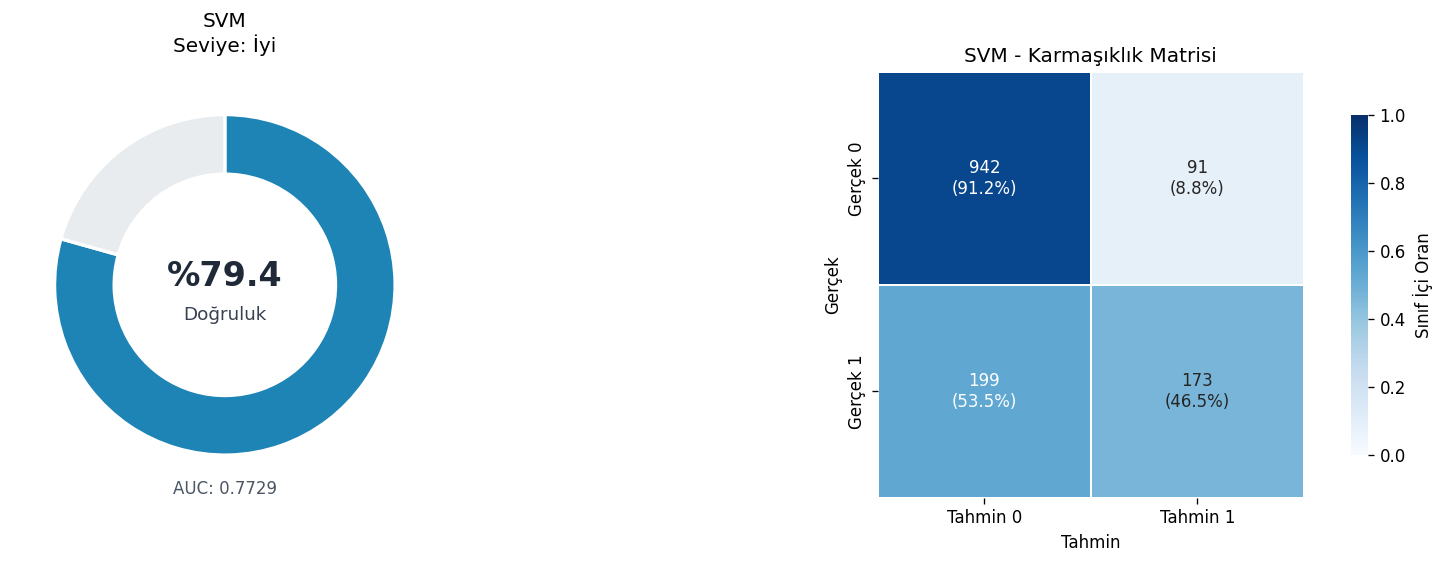

In [37]:
# Model 3 - SVM
svm_model = SVC(random_state=42, probability=True)
evaluate_and_store_model(
    model_name='SVM',
    model=svm_model,
    use_scaled_data=True
)


MODEL: Gradient Boosting
Ölçeklendirilmiş veri kullanımı: Hayır
5-Fold CV Accuracy Ortalama: 0.7929
5-Fold CV Accuracy Std: 0.0062
Test Accuracy: 0.7900
AUC Score: 0.8253

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       932       101
Gerçek 1       194       178


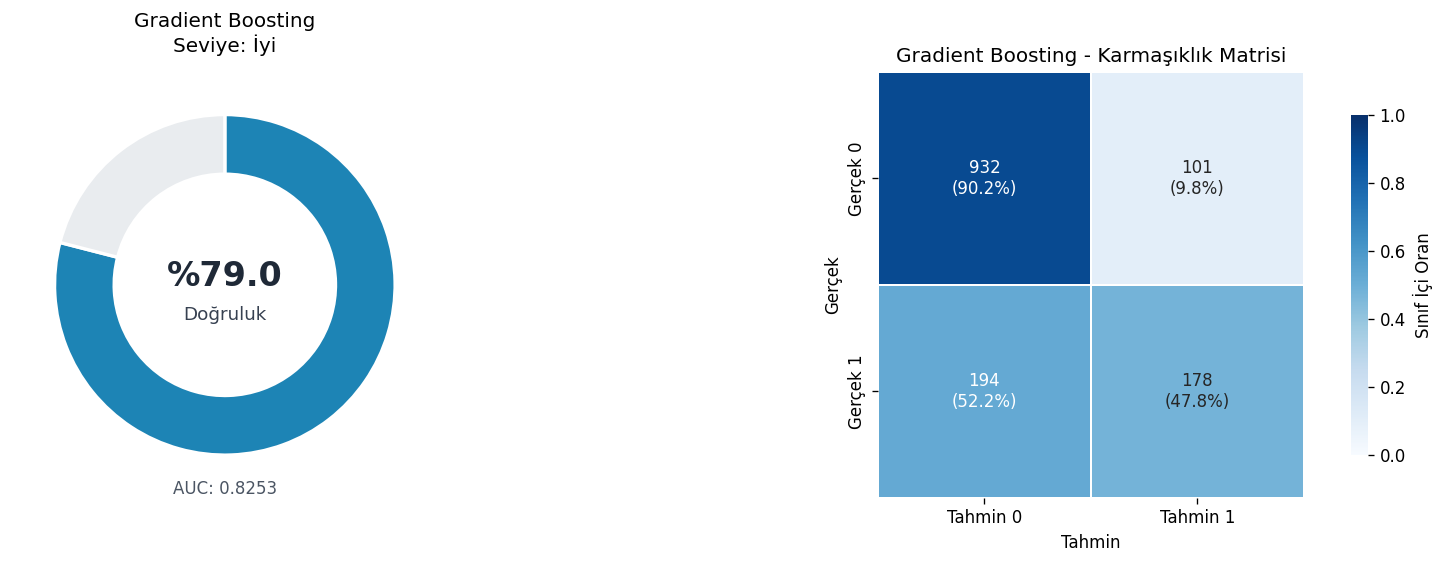

In [38]:
# Model 4 - Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
evaluate_and_store_model(
    model_name='Gradient Boosting',
    model=gb_model,
    use_scaled_data=False
)


MODEL: AdaBoost
Ölçeklendirilmiş veri kullanımı: Hayır
5-Fold CV Accuracy Ortalama: 0.7949
5-Fold CV Accuracy Std: 0.0041
Test Accuracy: 0.7829
AUC Score: 0.8257

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.63      0.44      0.52       372

    accuracy                           0.78      1405
   macro avg       0.72      0.67      0.69      1405
weighted avg       0.77      0.78      0.77      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       935        98
Gerçek 1       207       165


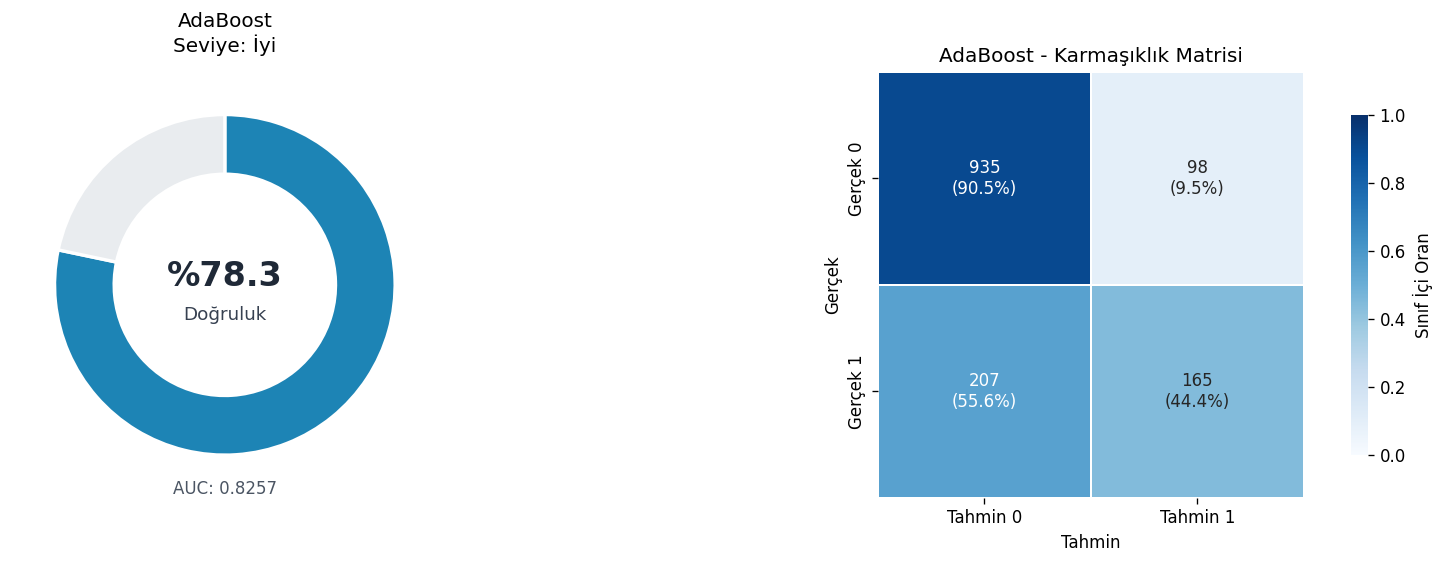

In [39]:
# Model 5 - AdaBoost
ada_model = AdaBoostClassifier(random_state=42)
evaluate_and_store_model(
    model_name='AdaBoost',
    model=ada_model,
    use_scaled_data=False
)


MODEL: Decision Tree
Ölçeklendirilmiş veri kullanımı: Hayır
5-Fold CV Accuracy Ortalama: 0.7295
5-Fold CV Accuracy Std: 0.0156
Test Accuracy: 0.7103
AUC Score: 0.6362

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.45      0.47      0.46       372

    accuracy                           0.71      1405
   macro avg       0.63      0.63      0.63      1405
weighted avg       0.71      0.71      0.71      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       825       208
Gerçek 1       199       173


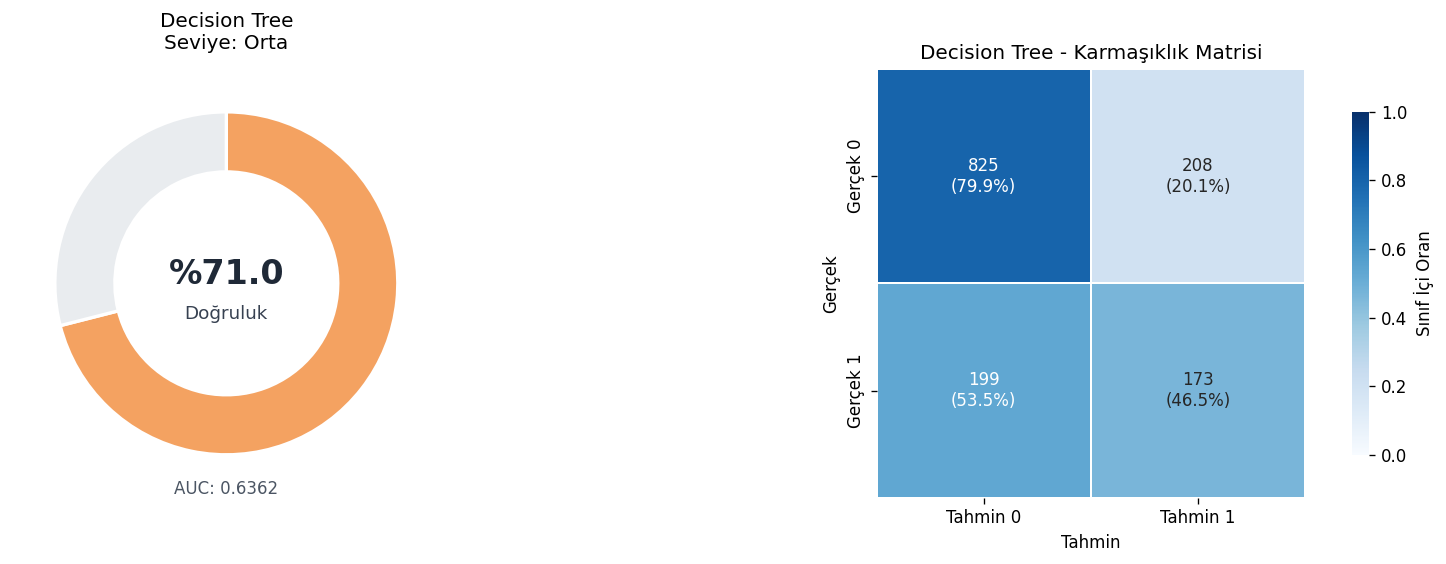

In [40]:
# Model 6 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
evaluate_and_store_model(
    model_name='Decision Tree',
    model=dt_model,
    use_scaled_data=False
)


MODEL: K-Nearest Neighbors
Ölçeklendirilmiş veri kullanımı: Evet
5-Fold CV Accuracy Ortalama: 0.7660
5-Fold CV Accuracy Std: 0.0138
Test Accuracy: 0.7836
AUC Score: 0.7808

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       372

    accuracy                           0.78      1405
   macro avg       0.72      0.70      0.71      1405
weighted avg       0.77      0.78      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       908       125
Gerçek 1       179       193


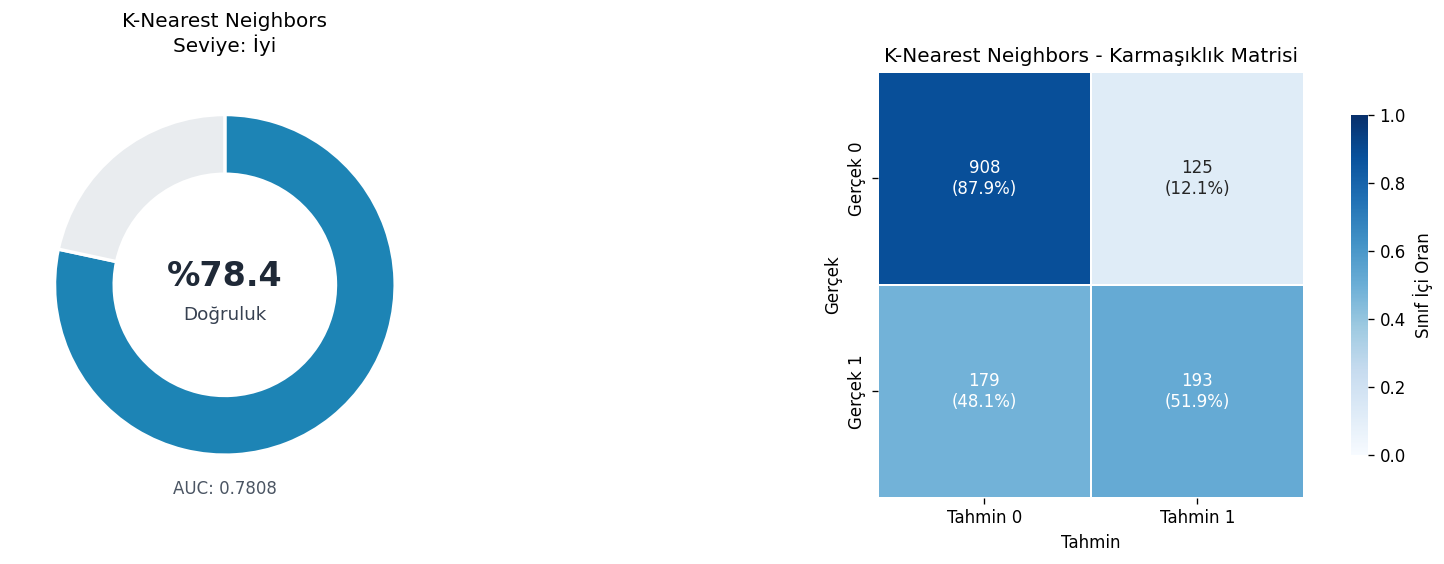

In [41]:
# Model 7 - K-Nearest Neighbors
knn_model = KNeighborsClassifier()
evaluate_and_store_model(
    model_name='K-Nearest Neighbors',
    model=knn_model,
    use_scaled_data=True
)


MODEL: Naive Bayes
Ölçeklendirilmiş veri kullanımı: Hayır
5-Fold CV Accuracy Ortalama: 0.6197
5-Fold CV Accuracy Std: 0.0160
Test Accuracy: 0.6114
AUC Score: 0.7986

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.93      0.51      0.66      1033
           1       0.40      0.90      0.55       372

    accuracy                           0.61      1405
   macro avg       0.67      0.70      0.60      1405
weighted avg       0.79      0.61      0.63      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       524       509
Gerçek 1        37       335


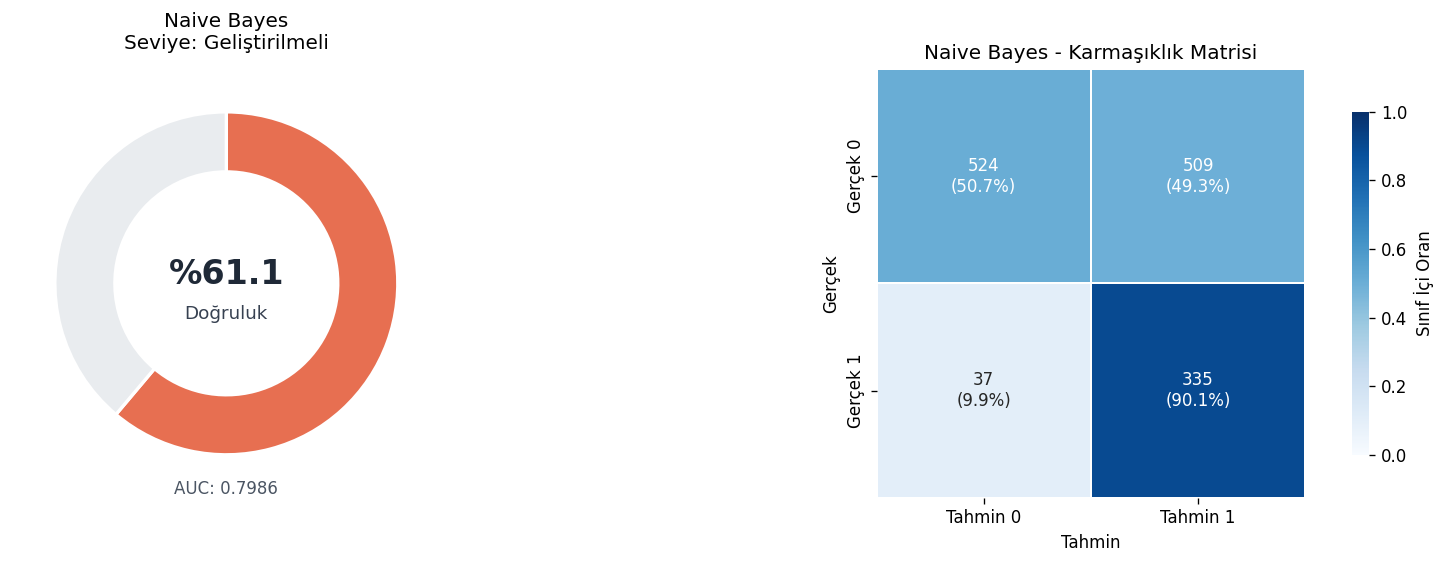

In [42]:
# Model 8 - Naive Bayes
nb_model = GaussianNB()
evaluate_and_store_model(
    model_name='Naive Bayes',
    model=nb_model,
    use_scaled_data=False
)

In [43]:
# Model sonuçlarının toplu karşılaştırması
print("\n" + "=" * 60)
print("MODEL KARŞILAŞTIRMASI")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'AUC': [results[model]['auc'] if not np.isnan(results[model]['auc']) else 0 for model in results],
    'CV_Mean': [results[model]['cv_mean'] for model in results],
    'CV_Std': [results[model]['cv_std'] for model in results]
})

comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df.round(4))

best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_model_acc = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Accuracy']
best_result = results[best_model_name]

print(f"\nEn iyi model: {best_model_name} (Accuracy: {best_model_acc:.4f})")
print(f"\n{best_model_name} Detaylı Raporu:")
print(classification_report(y_test, best_result['predictions']))


MODEL KARŞILAŞTIRMASI
                 Model  Accuracy     AUC  CV_Mean  CV_Std
0  Logistic Regression    0.7936  0.8293   0.7975  0.0017
1                  SVM    0.7936  0.7729   0.7926  0.0047
2    Gradient Boosting    0.7900  0.8253   0.7929  0.0062
3  K-Nearest Neighbors    0.7836  0.7808   0.7660  0.0138
4             AdaBoost    0.7829  0.8257   0.7949  0.0041
5        Random Forest    0.7680  0.7847   0.7644  0.0123
6        Decision Tree    0.7103  0.6362   0.7295  0.0156
7          Naive Bayes    0.6114  0.7986   0.6197  0.0160

En iyi model: Logistic Regression (Accuracy: 0.7936)

Logistic Regression Detaylı Raporu:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.47      0.55       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405



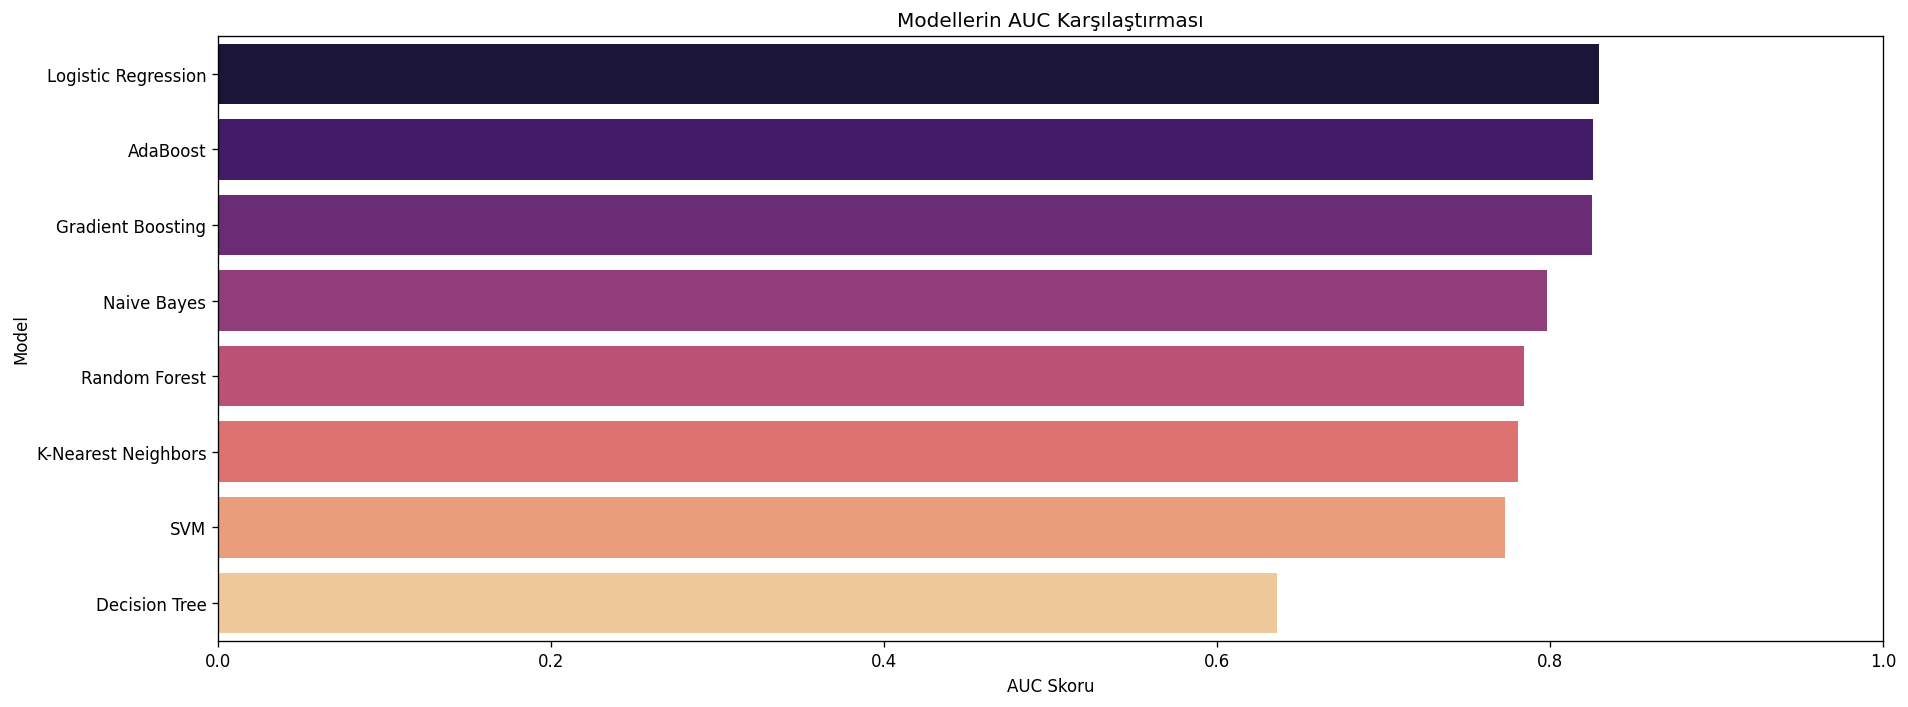

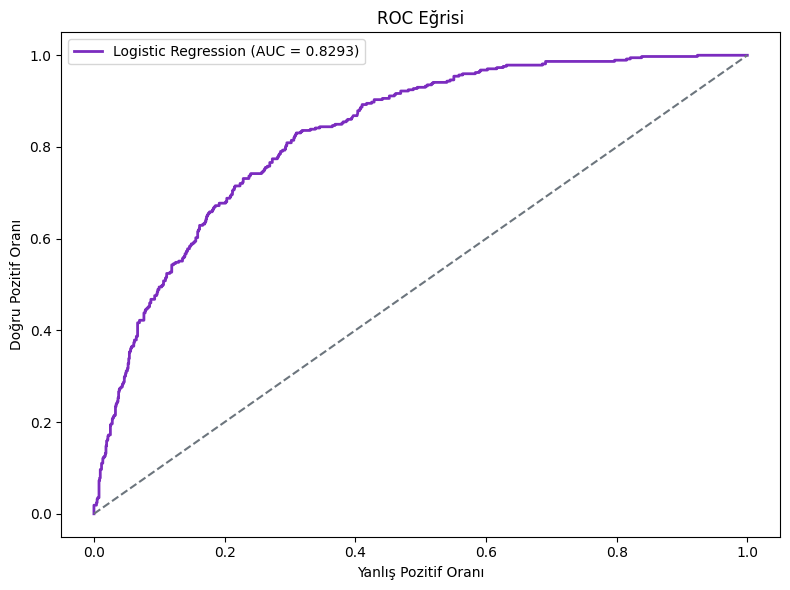

In [44]:
# Model karşılaştırması - AUC grafiği
plt.figure(figsize=(16, 6), dpi=120)
sns.barplot(
    data=comparison_df.sort_values('AUC', ascending=False),
    x='AUC',
    y='Model',
    palette='magma'
)
plt.title('Modellerin AUC Karşılaştırması')
plt.xlabel('AUC Skoru')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# En iyi model - ROC grafiği
if best_result['predictions_proba'] is not None:
    fpr, tpr, _ = roc_curve(y_test, best_result['predictions_proba'])
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='#7b2cbf', linewidth=2, label=f'{best_model_name} (AUC = {best_result["auc"]:.4f})')
    plt.plot([0, 1], [0, 1], color='#6c757d', linestyle='--')
    plt.xlabel('Yanlış Pozitif Oranı')
    plt.ylabel('Doğru Pozitif Oranı')
    plt.title('ROC Eğrisi')
    plt.legend()
    plt.tight_layout()
    plt.show()

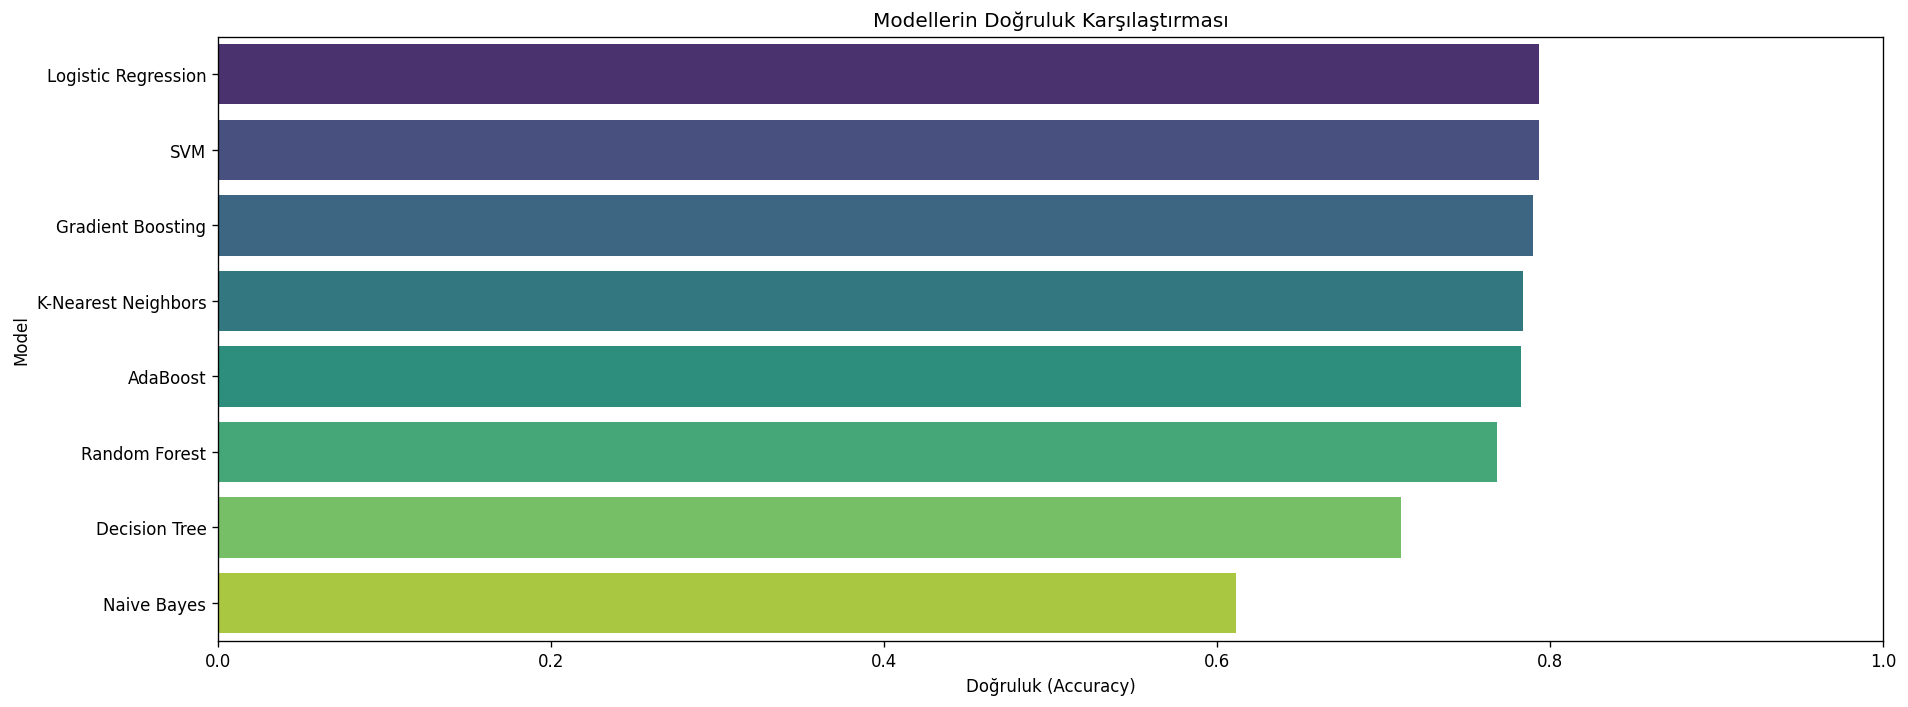

In [45]:
# Model karşılaştırması - Accuracy grafiği
plt.figure(figsize=(16, 6), dpi=120)
sns.barplot(
    data=comparison_df.sort_values('Accuracy', ascending=False),
    x='Accuracy',
    y='Model',
    palette='viridis'
)
plt.title('Modellerin Doğruluk Karşılaştırması')
plt.xlabel('Doğruluk (Accuracy)')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 6.1 Sınıflandırma İçin Kullanılan Temel Yöntemler



- ID3 yaklaşımı (Decision Tree - entropy)
- C4.5 yaklaşımı (entropy tabanlı, budama benzeri kısıtlarla)
- CART / Gini yaklaşımı (Decision Tree - gini)
- k-En Yakın Komşu (k-NN)
- Naive Bayes
- SVM



In [46]:
# Sınıflandırma yöntemleri - hazırlık ve değerlendirme altyapısı
print("=== SINIFLANDIRMA YÖNTEMLERİ AYRI KARŞILAŞTIRMA ===")

X_cls = df_selected.drop('Churn', axis=1)
y_cls = df_selected['Churn']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

classification_results = {}
classification_scale_required_models = ['k-NN (k=5)', 'SVM (RBF)']

def evaluate_and_store_classification_model(model_name, model, use_scaled_data=False):
    train_input = X_train_cls_scaled if use_scaled_data else X_train_cls
    test_input = X_test_cls_scaled if use_scaled_data else X_test_cls

    print("\n" + "=" * 70)
    print(f"YÖNTEM: {model_name}")
    print("=" * 70)
    print(f"Ölçeklendirilmiş veri kullanımı: {'Evet' if use_scaled_data else 'Hayır'}")

    model.fit(train_input, y_train_cls)
    y_pred_cls = model.predict(test_input)
    y_proba_cls = model.predict_proba(test_input)[:, 1]

    acc = accuracy_score(y_test_cls, y_pred_cls)
    auc = roc_auc_score(y_test_cls, y_proba_cls)
    cm = confusion_matrix(y_test_cls, y_pred_cls)

    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(y_test_cls, y_pred_cls))

    cm_df = pd.DataFrame(
        cm,
        index=['Gerçek 0', 'Gerçek 1'],
        columns=['Tahmin 0', 'Tahmin 1']
    )
    print("Karmaşıklık Matrisi:")
    print(cm_df)

    if acc >= 0.80:
        perf_label, perf_color = 'Çok İyi', '#2a9d8f'
    elif acc >= 0.75:
        perf_label, perf_color = 'İyi', '#1d84b5'
    elif acc >= 0.70:
        perf_label, perf_color = 'Orta', '#f4a261'
    else:
        perf_label, perf_color = 'Geliştirilmeli', '#e76f51'

    _, axes = plt.subplots(
        1,
        2,
        figsize=(14, 4.8),
        dpi=120,
        gridspec_kw={'width_ratios': [1, 1.25]}
    )

    axes[0].pie(
        [acc, 1 - acc],
        startangle=90,
        counterclock=False,
        colors=[perf_color, '#e9ecef'],
        wedgeprops={'width': 0.35, 'edgecolor': 'white', 'linewidth': 2}
    )
    axes[0].text(
        0,
        0.05,
        f"%{acc * 100:.1f}",
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold',
        color='#1f2937'
    )
    axes[0].text(
        0,
        -0.18,
        'Doğruluk',
        ha='center',
        va='center',
        fontsize=11,
        color='#374151'
    )
    axes[0].set_title(f"{model_name}\nSeviye: {perf_label}", pad=12)
    axes[0].text(
        0,
        -1.20,
        f"AUC: {auc:.4f}",
        ha='center',
        va='center',
        fontsize=10,
        color='#4b5563'
    )

    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    annot = np.array([
        [f"{cm[i, j]}\n({cm_pct[i, j] * 100:.1f}%)" for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    sns.heatmap(
        cm_pct,
        annot=annot,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=1,
        cbar=True,
        square=True,
        linewidths=1.2,
        linecolor='white',
        xticklabels=['Tahmin 0', 'Tahmin 1'],
        yticklabels=['Gerçek 0', 'Gerçek 1'],
        ax=axes[1],
        cbar_kws={'shrink': 0.8, 'label': 'Sınıf İçi Oran'}
    )
    axes[1].set_title(f"{model_name} - Karmaşıklık Matrisi")
    axes[1].set_xlabel('Tahmin')
    axes[1].set_ylabel('Gerçek')

    plt.tight_layout()
    plt.show()

    classification_results[model_name] = {
        'model': model,
        'accuracy': acc,
        'auc': auc,
        'predictions': y_pred_cls,
        'predictions_proba': y_proba_cls,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_test_cls, y_pred_cls, output_dict=True)
    }

print("4.1 yöntem hazırlığı tamamlandı. Aşağıdaki hücrelerde yöntemler tek tek eğitilecektir.")

=== SINIFLANDIRMA YÖNTEMLERİ AYRI KARŞILAŞTIRMA ===
4.1 yöntem hazırlığı tamamlandı. Aşağıdaki hücrelerde yöntemler tek tek eğitilecektir.



YÖNTEM: ID3 (Entropy)
Ölçeklendirilmiş veri kullanımı: Hayır
Accuracy: 0.7096
AUC: 0.6385

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.45      0.47      0.46       372

    accuracy                           0.71      1405
   macro avg       0.63      0.63      0.63      1405
weighted avg       0.71      0.71      0.71      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       822       211
Gerçek 1       197       175


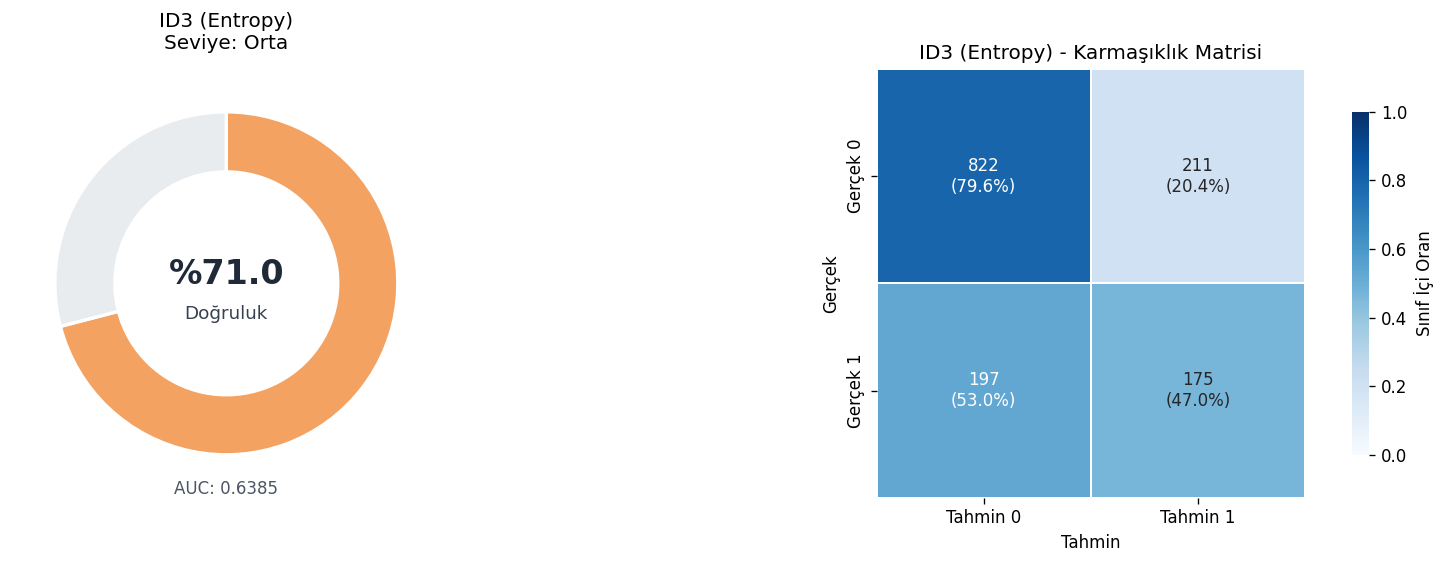

In [47]:
# 4.1 Yöntem 1 - ID3 (Entropy)
id3_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
evaluate_and_store_classification_model(
    model_name='ID3 (Entropy)',
    model=id3_model,
    use_scaled_data=False
)


YÖNTEM: C4.5 Yaklaşımı (Entropy + Pruning Benzeri)
Ölçeklendirilmiş veri kullanımı: Hayır
Accuracy: 0.7872
AUC: 0.8097

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.61      0.55      0.58       372

    accuracy                           0.79      1405
   macro avg       0.73      0.71      0.72      1405
weighted avg       0.78      0.79      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       901       132
Gerçek 1       167       205


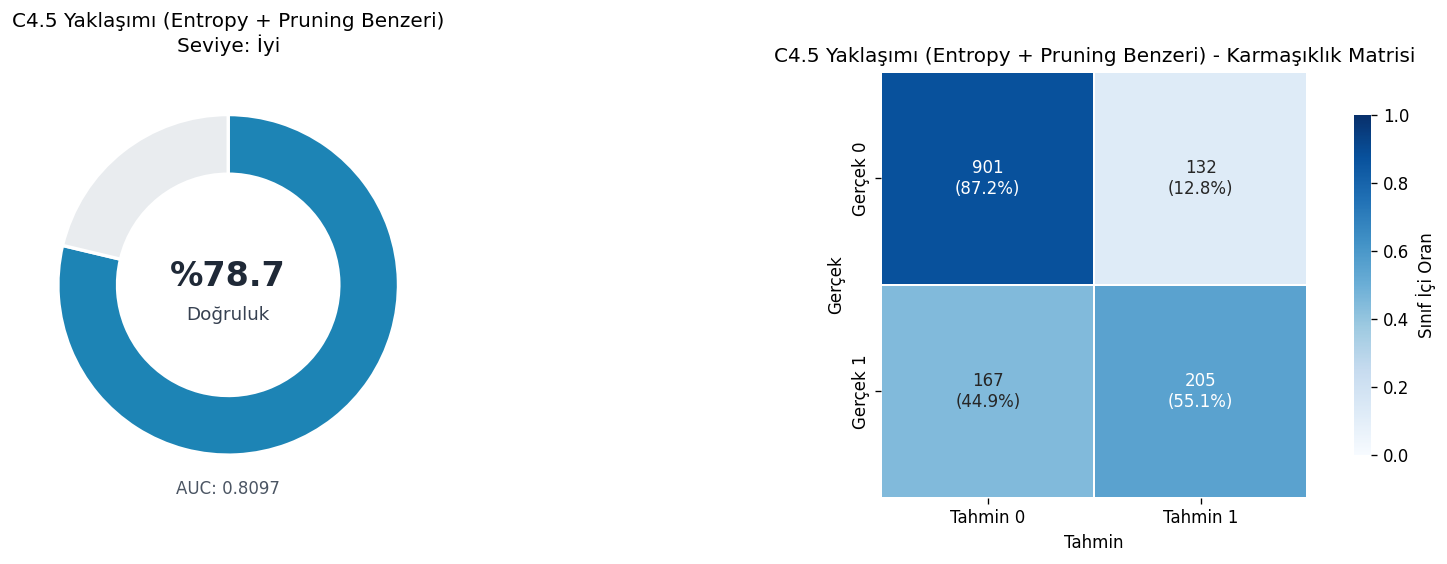

In [48]:
# 4.1 Yöntem 2 - C4.5 Yaklaşımı
c45_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=0.001
)
evaluate_and_store_classification_model(
    model_name='C4.5 Yaklaşımı (Entropy + Pruning Benzeri)',
    model=c45_model,
    use_scaled_data=False
)


YÖNTEM: CART (Gini)
Ölçeklendirilmiş veri kullanımı: Hayır
Accuracy: 0.7103
AUC: 0.6362

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.45      0.47      0.46       372

    accuracy                           0.71      1405
   macro avg       0.63      0.63      0.63      1405
weighted avg       0.71      0.71      0.71      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       825       208
Gerçek 1       199       173


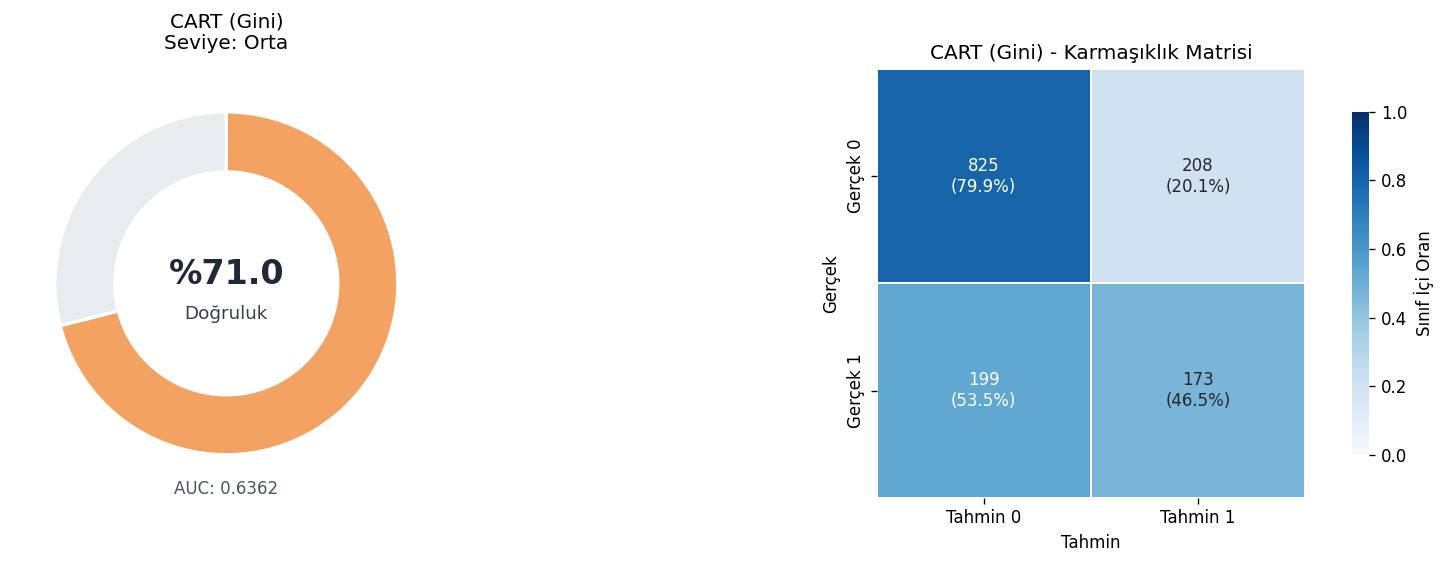

In [49]:
# 4.1 Yöntem 3 - CART (Gini)
cart_model = DecisionTreeClassifier(criterion='gini', random_state=42)
evaluate_and_store_classification_model(
    model_name='CART (Gini)',
    model=cart_model,
    use_scaled_data=False
)


YÖNTEM: k-NN (k=5)
Ölçeklendirilmiş veri kullanımı: Evet
Accuracy: 0.7836
AUC: 0.7808

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.52      0.56       372

    accuracy                           0.78      1405
   macro avg       0.72      0.70      0.71      1405
weighted avg       0.77      0.78      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       908       125
Gerçek 1       179       193


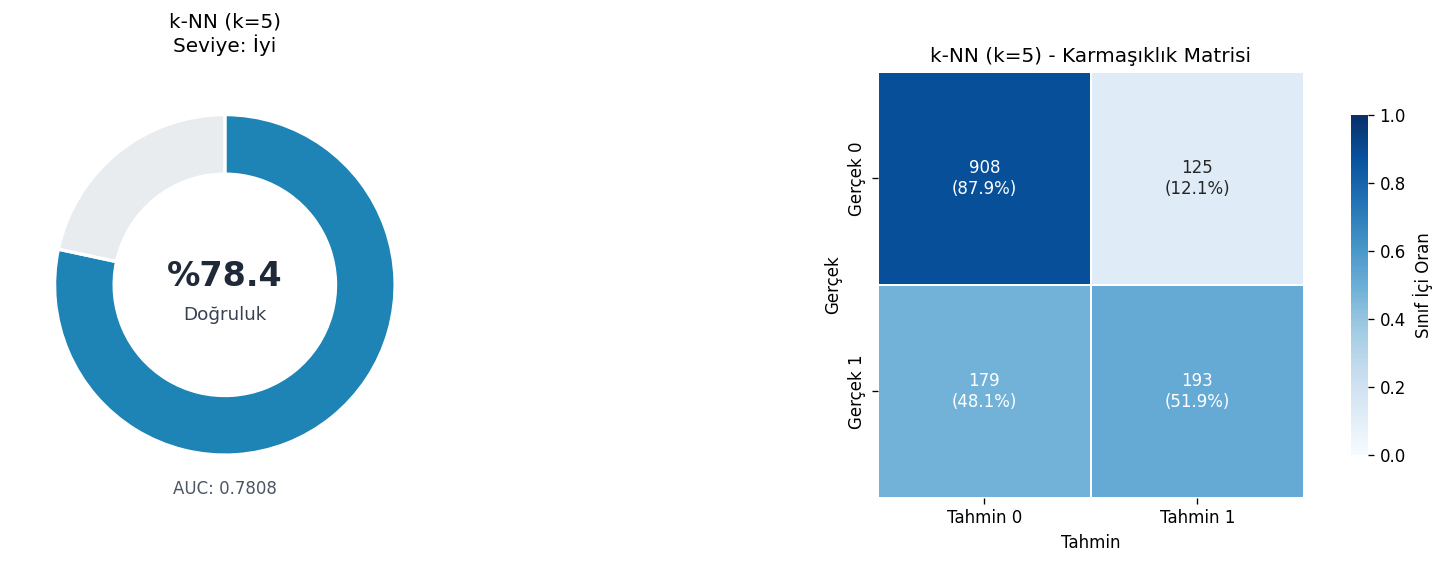

In [50]:
# 4.1 Yöntem 4 - k-NN (k=5)
knn_cls_model = KNeighborsClassifier(n_neighbors=5)
evaluate_and_store_classification_model(
    model_name='k-NN (k=5)',
    model=knn_cls_model,
    use_scaled_data=True
)


YÖNTEM: Naive Bayes
Ölçeklendirilmiş veri kullanımı: Hayır
Accuracy: 0.6114
AUC: 0.7986

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.93      0.51      0.66      1033
           1       0.40      0.90      0.55       372

    accuracy                           0.61      1405
   macro avg       0.67      0.70      0.60      1405
weighted avg       0.79      0.61      0.63      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       524       509
Gerçek 1        37       335


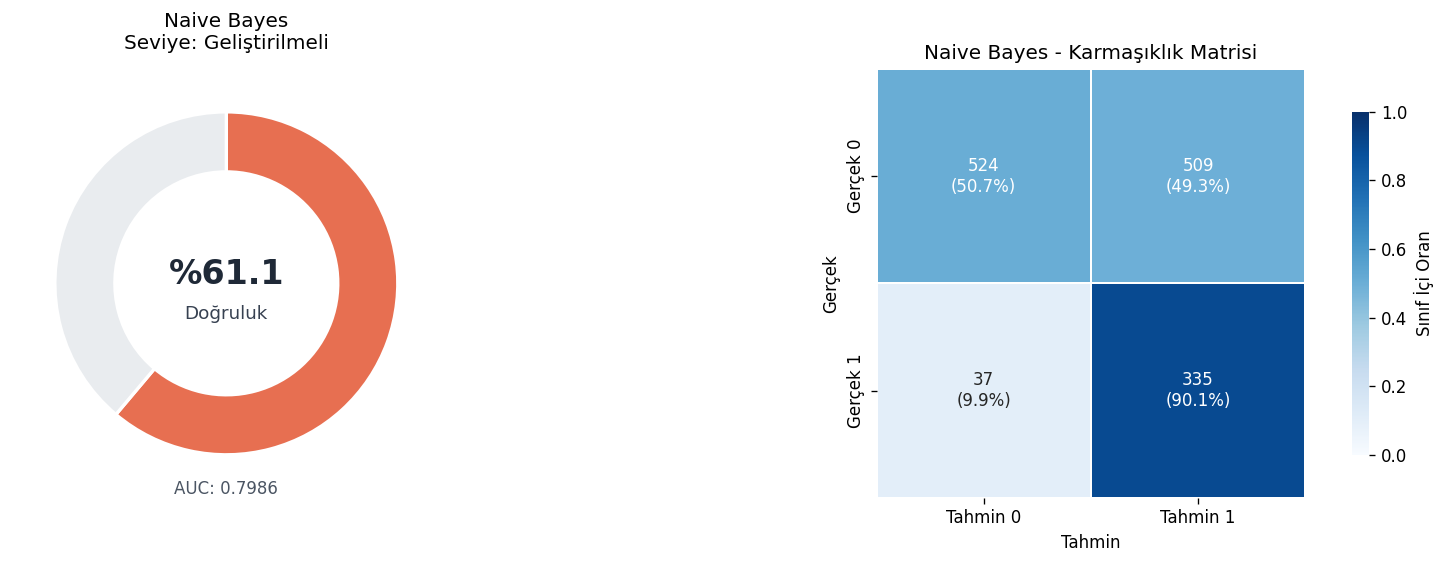

In [51]:
# 4.1 Yöntem 5 - Naive Bayes
nb_cls_model = GaussianNB()
evaluate_and_store_classification_model(
    model_name='Naive Bayes',
    model=nb_cls_model,
    use_scaled_data=False
)


YÖNTEM: SVM (RBF)
Ölçeklendirilmiş veri kullanımı: Evet
Accuracy: 0.7936
AUC: 0.7729

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.54       372

    accuracy                           0.79      1405
   macro avg       0.74      0.69      0.71      1405
weighted avg       0.78      0.79      0.78      1405

Karmaşıklık Matrisi:
          Tahmin 0  Tahmin 1
Gerçek 0       942        91
Gerçek 1       199       173


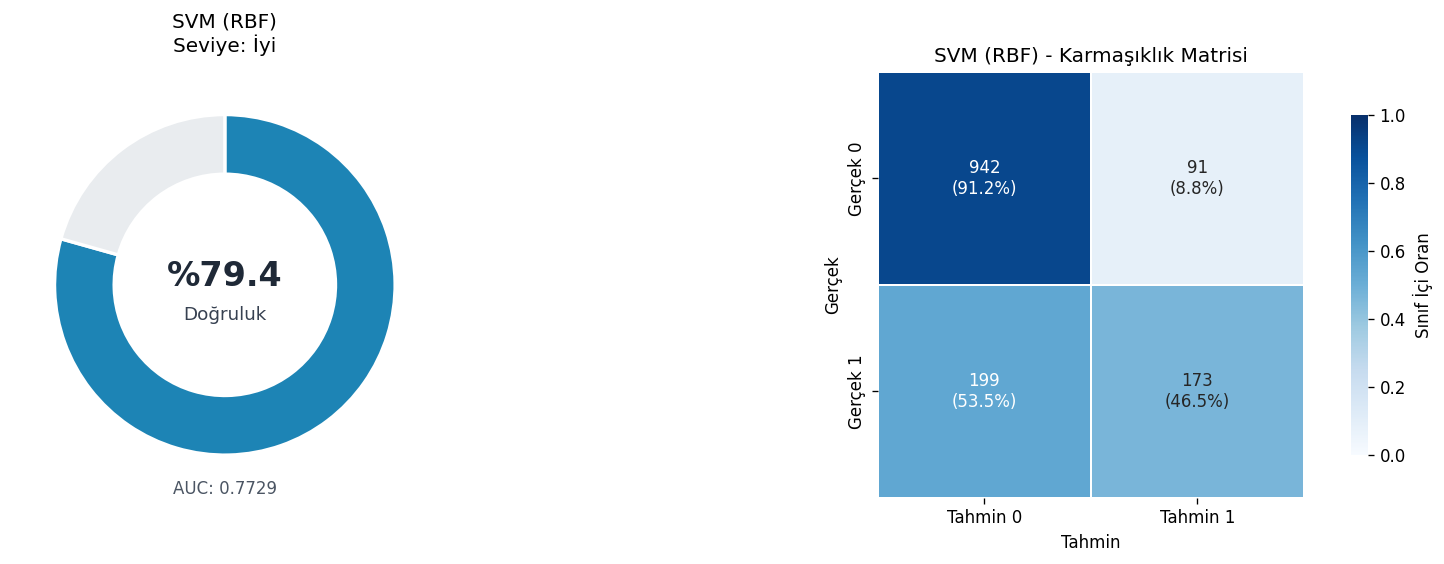

In [52]:
# 4.1 Yöntem 6 - SVM (RBF)
svm_cls_model = SVC(kernel='rbf', probability=True, random_state=42)
evaluate_and_store_classification_model(
    model_name='SVM (RBF)',
    model=svm_cls_model,
    use_scaled_data=True
)

In [53]:
# 4.1 yöntem sonuçlarının toplu karşılaştırması
classification_df = pd.DataFrame({
    'Model': list(classification_results.keys()),
    'Accuracy': [classification_results[model]['accuracy'] for model in classification_results],
    'AUC': [classification_results[model]['auc'] for model in classification_results]
})

classification_df = classification_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

separator = '=' * 70
print('\n' + separator)
print('SINIFLANDIRMA YÖNTEMLERİ SONUÇ TABLOSU')
print(separator)
print(classification_df.round(4))

best_cls_row = classification_df.iloc[0]
best_cls_model = best_cls_row['Model']
best_cls_acc = best_cls_row['Accuracy']
print(f"\nEn iyi sınıflandırma yöntemi: {best_cls_model} (Accuracy: {best_cls_acc:.4f})")


SINIFLANDIRMA YÖNTEMLERİ SONUÇ TABLOSU
                                        Model  Accuracy     AUC
0                                   SVM (RBF)    0.7936  0.7729
1  C4.5 Yaklaşımı (Entropy + Pruning Benzeri)    0.7872  0.8097
2                                  k-NN (k=5)    0.7836  0.7808
3                                 CART (Gini)    0.7103  0.6362
4                               ID3 (Entropy)    0.7096  0.6385
5                                 Naive Bayes    0.6114  0.7986

En iyi sınıflandırma yöntemi: SVM (RBF) (Accuracy: 0.7936)


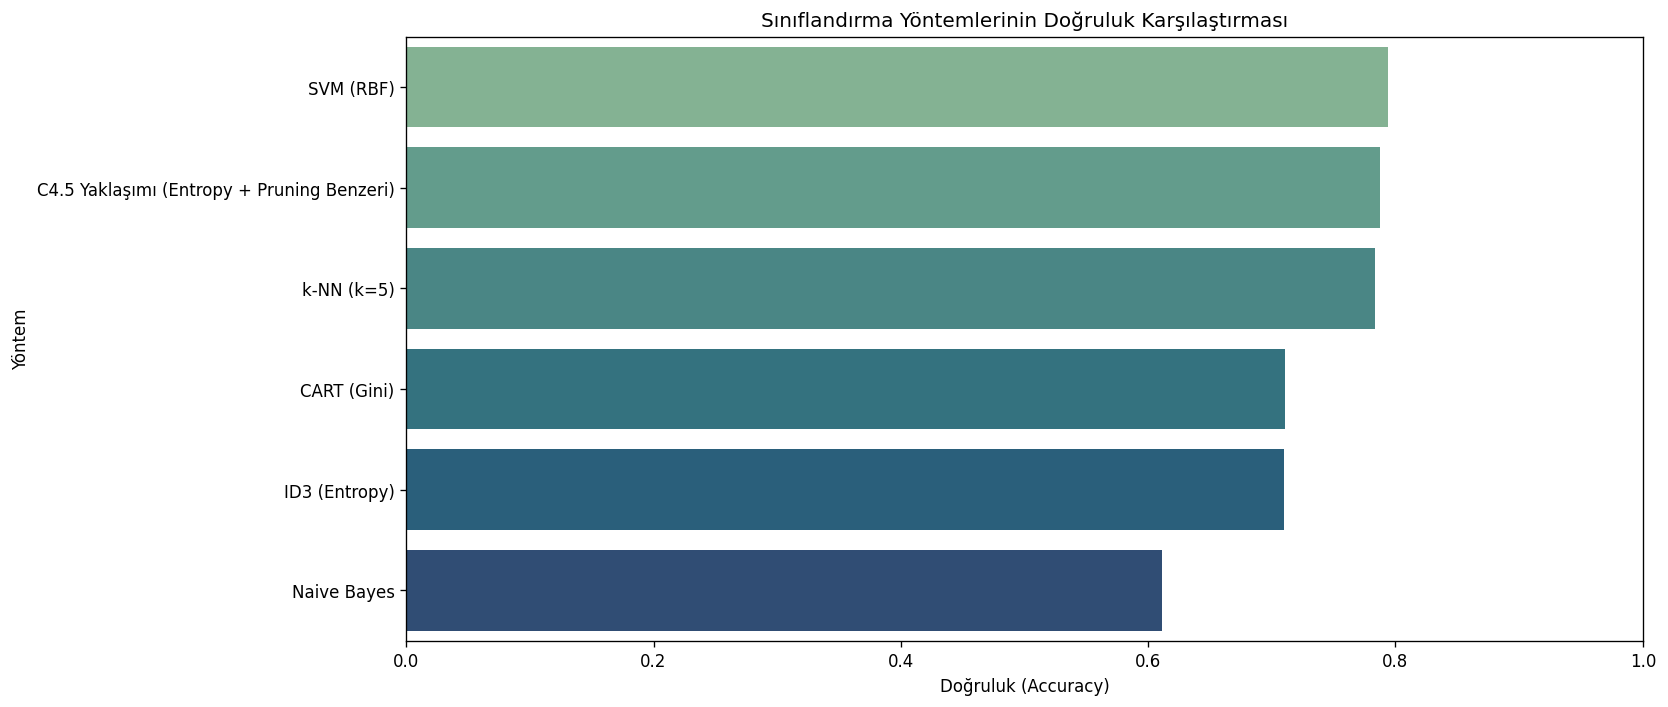

In [54]:
# Sınıflandırma yöntemleri - Accuracy grafiği
plt.figure(figsize=(14, 6), dpi=120)
sns.barplot(
    data=classification_df,
    x='Accuracy',
    y='Model',
    palette='crest'
)
plt.title('Sınıflandırma Yöntemlerinin Doğruluk Karşılaştırması')
plt.xlabel('Doğruluk (Accuracy)')
plt.ylabel('Yöntem')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()